In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# ══════════════════════════════════════════════════════════════════
# INSTALL LOOPZ
# ══════════════════════════════════════════════════════════════════
!pip install -q git+https://github.com/Shiv0087/loopz.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
# ══════════════════════════════════════════════════════════════════
# CELL 1 — Imports & Configuration
# ══════════════════════════════════════════════════════════════════

import os, json, cv2, time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms, models
from torchvision.models import (
    efficientnet_b4, EfficientNet_B4_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
)
from PIL import Image
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score,
    accuracy_score, confusion_matrix,
    average_precision_score
)
from scipy import stats
from itertools import combinations

# ── Loopz imports ──────────────────────────────────────────────
try:
    from loopz import Experiment, CheckpointManager, Logger
    from loopz.utils import save_checkpoint, load_checkpoint
    from loopz.tracking import MetricTracker
    LOOPZ_AVAILABLE = True
    print("  ✓ Loopz imported successfully")
except ImportError:
    LOOPZ_AVAILABLE = False
    print("  ⚠ Loopz not available — using fallback checkpoint system")

# ── Configuration ──────────────────────────────────────────────
CFG = {
    # paths
    'base_dir'    : '/kaggle/input/datasets/himachhatbar1700/deepfake',
    'cache_dir'   : '/kaggle/input/datasets/himachhatbar1700/deepfake/cache',
    'split_dir'   : '/kaggle/input/datasets/himachhatbar1700/deepfake/split',
    'output_dir'  : '/kaggle/working/',

    # loopz experiment settings
    'experiment_name'    : 'deepfake_detection_ieee',
    'experiment_version' : 'v1.0',
    'loopz_dir'          : '/kaggle/working/loopz_experiments',
    'checkpoint_dir'     : '/kaggle/working/loopz_experiments/checkpoints',
    'logs_dir'           : '/kaggle/working/loopz_experiments/logs',

    # training
    'img_size'    : 224,
    'batch_size'  : 32,
    'epochs'      : 10,
    'lr'          : 3e-4,
    'weight_decay': 1e-4,
    'warmup_ep'   : 3,
    'label_smooth': 0.1,
    'num_workers' : 2,
    'seed'        : 42,

    # features
    'fft_size'    : 56,
    'flow_size'   : 56,

    # ── threshold for deepfake classification ──────────────────
    'threshold'   : 0.7,
    # ──────────────────────────────────────────────────────────

    # device
    'device'      : 'cuda' if torch.cuda.is_available() else 'cpu',
}

# ── Create all directories ─────────────────────────────────────
for d in [CFG['output_dir'], CFG['loopz_dir'],
          CFG['checkpoint_dir'], CFG['logs_dir']]:
    os.makedirs(d, exist_ok=True)

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])

print("="*60)
print("  IEEE DeepFake Detection Pipeline")
print("  3 Models: SDB | DSFN | MSTF-Trans")
print("  Checkpoint Manager: Loopz Framework")
print("="*60)
print(f"  Device          : {CFG['device']}")
print(f"  Batch Size      : {CFG['batch_size']}")
print(f"  Epochs          : {CFG['epochs']}")
print(f"  Image Size      : {CFG['img_size']}×{CFG['img_size']}")
print(f"  Output Dir      : {CFG['output_dir']}")
print(f"  Loopz Dir       : {CFG['loopz_dir']}")
print(f"  Threshold       : {CFG['threshold']}  ← deepfake classification cutoff")
print(f"  Experiment      : {CFG['experiment_name']} {CFG['experiment_version']}")
print("="*60)

if torch.cuda.is_available():
    print(f"\n  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

  ⚠ Loopz not available — using fallback checkpoint system
  IEEE DeepFake Detection Pipeline
  3 Models: SDB | DSFN | MSTF-Trans
  Checkpoint Manager: Loopz Framework
  Device          : cuda
  Batch Size      : 32
  Epochs          : 10
  Image Size      : 224×224
  Output Dir      : /kaggle/working/
  Loopz Dir       : /kaggle/working/loopz_experiments
  Threshold       : 0.7  ← deepfake classification cutoff
  Experiment      : deepfake_detection_ieee v1.0

  GPU : Tesla T4
  VRAM: 15.6 GB


In [40]:
# ══════════════════════════════════════════════════════════════════
# LOOPZ SETUP CELL — Experiment & Checkpoint Manager
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  Loopz Experiment Setup")
print("="*60)

# ── Loopz Experiment Manager ───────────────────────────────────
class LoopzCheckpointManager:
    """
    Wrapper around Loopz framework for checkpoint management.
    Handles save/load of model weights, optimizer states,
    scheduler states, and training metadata.

    Falls back to standard torch.save if Loopz unavailable.
    """

    def __init__(self, cfg, model_name):
        self.cfg        = cfg
        self.model_name = model_name
        self.ckpt_dir   = os.path.join(
            cfg['checkpoint_dir'], model_name)
        os.makedirs(self.ckpt_dir, exist_ok=True)

        self.best_auc    = 0.0
        self.best_epoch  = 0
        self.history     = []
        self.metric_log  = []

        # ── Loopz experiment ──
        if LOOPZ_AVAILABLE:
            try:
                self.experiment = Experiment(
                    name    = f"{cfg['experiment_name']}_{model_name}",
                    version = cfg['experiment_version'],
                    log_dir = cfg['logs_dir'],
                )
                self.ckpt_manager = CheckpointManager(
                    checkpoint_dir = self.ckpt_dir,
                    max_checkpoints= 3,          # keep only 3 best
                )
                self.logger = Logger(
                    experiment  = self.experiment,
                    log_console = True,
                )
                self.loopz_active = True
                print(f"  ✓ Loopz experiment: "
                      f"{cfg['experiment_name']}_{model_name}")
            except Exception as e:
                print(f"  ⚠ Loopz init failed ({e}) — using fallback")
                self.loopz_active = False
        else:
            self.loopz_active = False

    def log_hyperparams(self, cfg):
        """Log hyperparameters to Loopz experiment."""
        hparams = {
            'lr'           : cfg['lr'],
            'batch_size'   : cfg['batch_size'],
            'epochs'       : cfg['epochs'],
            'weight_decay' : cfg['weight_decay'],
            'warmup_ep'    : cfg['warmup_ep'],
            'label_smooth' : cfg['label_smooth'],
            'img_size'     : cfg['img_size'],
            'threshold'    : cfg['threshold'],
            'seed'         : cfg['seed'],
        }
        if self.loopz_active:
            try:
                self.experiment.log_hyperparams(hparams)
                print(f"  ✓ [{self.model_name}] Hyperparams logged to Loopz")
            except Exception as e:
                print(f"  ⚠ Loopz hparam log failed: {e}")

        # Always save to JSON as fallback
        hp_path = os.path.join(self.ckpt_dir, 'hyperparams.json')
        with open(hp_path, 'w') as f:
            json.dump(hparams, f, indent=2)

    def log_metrics(self, epoch, metrics_dict):
        """Log epoch metrics to Loopz."""
        self.metric_log.append({'epoch': epoch, **metrics_dict})

        if self.loopz_active:
            try:
                self.logger.log_metrics(metrics_dict, step=epoch)
            except Exception as e:
                pass  # silent fallback

        # Always append to JSONL
        log_path = os.path.join(self.ckpt_dir, 'metrics.jsonl')
        with open(log_path, 'a') as f:
            f.write(json.dumps({'epoch': epoch, **metrics_dict}) + '\n')

    def save_checkpoint(self, model, optimizer, scheduler,
                        epoch, metrics, is_best=False):
        """
        Save checkpoint using Loopz CheckpointManager.
        Falls back to torch.save if Loopz unavailable.
        """
        state = {
            'epoch'         : epoch,
            'model_state'   : model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'metrics'       : {
                k: float(v)
                for k, v in metrics.items()
                if isinstance(v, (int, float, np.floating))
            },
            'best_auc'      : self.best_auc,
            'threshold'     : self.cfg['threshold'],
            'model_name'    : self.model_name,
            'timestamp'     : time.strftime('%Y-%m-%d %H:%M:%S'),
        }

        # ── Loopz save ──
        if self.loopz_active:
            try:
                ckpt_path = self.ckpt_manager.save(
                    state   = state,
                    step    = epoch,
                    metrics = {'auc': float(metrics.get('auc', 0))},
                )
                print(f"  [Loopz] ✓ Saved checkpoint: {ckpt_path}")
            except Exception as e:
                print(f"  [Loopz] ⚠ Save failed ({e}) — fallback")
                self._fallback_save(state, epoch, is_best)
        else:
            self._fallback_save(state, epoch, is_best)

        # Always save best separately
        if is_best:
            best_path = os.path.join(
                self.ckpt_dir, f'best_{self.model_name}.pt')
            torch.save(state, best_path)
            print(f"  ★  Best checkpoint → {best_path}")
            self.best_epoch = epoch

        # Also save to original output_dir for compatibility
        torch.save(
            model.state_dict(),
            f"{self.cfg['output_dir']}/best_{self.model_name}.pt"
        )

        return state

    def _fallback_save(self, state, epoch, is_best):
        """Standard torch.save fallback."""
        path = os.path.join(
            self.ckpt_dir,
            f'{self.model_name}_ep{epoch:03d}.pt'
        )
        torch.save(state, path)
        print(f"  [Fallback] Saved: {path}")

    def load_best(self, model, device, optimizer=None,
                  scheduler=None):
        """
        Load the best checkpoint for this model.
        Tries Loopz first, then fallback file.
        """
        best_path = os.path.join(
            self.ckpt_dir, f'best_{self.model_name}.pt')

        if not os.path.exists(best_path):
            print(f"  ⚠ No checkpoint found at {best_path}")
            return None

        state = torch.load(best_path, map_location=device)
        model.load_state_dict(state['model_state'])
        print(f"  ✓ Loaded best checkpoint "
              f"(epoch={state['epoch']}, "
              f"AUC={state['metrics'].get('auc',0):.4f})")

        if optimizer and 'optimizer_state' in state:
            optimizer.load_state_dict(state['optimizer_state'])
        if scheduler and 'scheduler_state' in state:
            scheduler.load_state_dict(state['scheduler_state'])

        return state

    def finalize(self, test_metrics):
        """Log final test results and close Loopz experiment."""
        final = {
            k: float(v)
            for k, v in test_metrics.items()
            if isinstance(v, (int, float, np.floating))
        }
        final['model_name']  = self.model_name
        final['best_epoch']  = self.best_epoch
        final['threshold']   = self.cfg['threshold']
        final['timestamp']   = time.strftime('%Y-%m-%d %H:%M:%S')

        # Save final results JSON
        results_path = os.path.join(
            self.ckpt_dir, 'final_results.json')
        with open(results_path, 'w') as f:
            json.dump(final, f, indent=2)
        print(f"  ✓ Final results → {results_path}")

        if self.loopz_active:
            try:
                self.logger.log_metrics(
                    {f'test_{k}': v for k, v in final.items()
                     if isinstance(v, (int, float))},
                    step=self.cfg['epochs'] + 1
                )
                self.experiment.finalize()
                print(f"  ✓ Loopz experiment finalized")
            except Exception as e:
                print(f"  ⚠ Loopz finalize error: {e}")

    def generate_report(self):
        """Generate training report from metric log."""
        if not self.metric_log:
            return

        report_path = os.path.join(
            self.ckpt_dir, 'training_report.json')
        report = {
            'model_name'   : self.model_name,
            'total_epochs' : len(self.metric_log),
            'best_auc'     : self.best_auc,
            'best_epoch'   : self.best_epoch,
            'threshold'    : self.cfg['threshold'],
            'history'      : self.metric_log,
        }
        with open(report_path, 'w') as f:
            json.dump(report, f, indent=2)
        print(f"  ✓ Training report → {report_path}")


# ── Instantiate managers (one per model) ──────────────────────
print("\n  Initializing checkpoint managers...")
checkpoint_managers = {}
for model_name in ['SDB', 'DSFN', 'MSTF-Trans']:
    checkpoint_managers[model_name] = LoopzCheckpointManager(
        CFG, model_name)

print("\n  Checkpoint directories:")
for name, mgr in checkpoint_managers.items():
    print(f"  {name:12s} → {mgr.ckpt_dir}")

print("\n  ✓ Loopz checkpoint system ready")


  Loopz Experiment Setup

  Initializing checkpoint managers...

  Checkpoint directories:
  SDB          → /kaggle/working/loopz_experiments/checkpoints/SDB
  DSFN         → /kaggle/working/loopz_experiments/checkpoints/DSFN
  MSTF-Trans   → /kaggle/working/loopz_experiments/checkpoints/MSTF-Trans

  ✓ Loopz checkpoint system ready


In [5]:
# ══════════════════════════════════════════════════════════════════
# CELL 2 — Load Cache & Build Dataset
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  CELL 2 — Loading Cached Features")
print("="*60)

print("\n[1/2] Loading FFT cache...")
fft_cache_path  = os.path.join(CFG['cache_dir'], 'fft_train.json')
flow_cache_path = os.path.join(CFG['cache_dir'], 'flow_train.json')

with open(fft_cache_path, 'r') as f:
    fft_cache_raw = json.load(f)
print(f"  ✓ FFT  cache loaded : {len(fft_cache_raw):,} entries")

print("\n[2/2] Loading Flow cache...")
with open(flow_cache_path, 'r') as f:
    flow_cache_raw = json.load(f)
print(f"  ✓ Flow cache loaded : {len(flow_cache_raw):,} entries")

print("\n[INFO] Inspecting cache structure...")
sample_fft_key  = list(fft_cache_raw.keys())[0]
sample_flow_key = list(flow_cache_raw.keys())[0]
print(f"  FFT  sample key : '{sample_fft_key}'")
print(f"  FFT  sample val : type={type(fft_cache_raw[sample_fft_key])}, "
      f"len={len(fft_cache_raw[sample_fft_key]) if isinstance(fft_cache_raw[sample_fft_key], list) else 'scalar'}")
print(f"  Flow sample key : '{sample_flow_key}'")
print(f"  Flow sample val : type={type(flow_cache_raw[sample_flow_key])}, "
      f"len={len(flow_cache_raw[sample_flow_key]) if isinstance(flow_cache_raw[sample_flow_key], list) else 'scalar'}")

print("\n[INFO] Converting cache to numpy arrays...")

def normalize_key(path_str):
    return Path(path_str).stem

fft_cache  = {}
for k, v in tqdm(fft_cache_raw.items(),
                  desc="  FFT  convert", leave=False):
    arr = np.array(v, dtype=np.float32)
    if arr.ndim == 1:
        side = int(np.sqrt(arr.shape[0]))
        arr  = arr.reshape(side, side)
    fft_cache[normalize_key(k)] = arr

flow_cache = {}
for k, v in tqdm(flow_cache_raw.items(),
                  desc="  Flow convert", leave=False):
    arr = np.array(v, dtype=np.float32)
    if arr.ndim == 1:
        side = int(np.sqrt(arr.shape[0]))
        arr  = arr.reshape(side, side)
    flow_cache[normalize_key(k)] = arr

print(f"  ✓ FFT  lookup : {len(fft_cache):,} arrays, "
      f"shape={list(fft_cache.values())[0].shape}")
print(f"  ✓ Flow lookup : {len(flow_cache):,} arrays, "
      f"shape={list(flow_cache.values())[0].shape}")
# ══════════════════════════════════════════════════════════════════
# CELL 3 — Scan Dataset & Build File Lists
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  CELL 3 — Scanning Dataset Structure")
print("="*60)

IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}
VID_EXTENSIONS = {'.mp4', '.avi', '.mov', '.mkv'}

def scan_split(split_dir, split_name):
    records = []
    base    = Path(split_dir) / split_name

    for media_type in ['images', 'videos']:
        for cls_name, label in [('fake', 1), ('real', 0)]:
            folder = base / media_type / cls_name
            if not folder.exists():
                print(f"  ⚠ Not found: {folder}")
                continue

            exts  = (IMG_EXTENSIONS if media_type == 'images'
                     else VID_EXTENSIONS)
            files = [f for f in folder.iterdir()
                     if f.suffix.lower() in exts]

            for f in files:
                records.append({
                    'path'  : str(f),
                    'label' : label,
                    'type'  : media_type[:-1],
                    'stem'  : f.stem,
                    'split' : split_name,
                })

            print(f"  {split_name:5s} | {media_type:6s} | "
                  f"{cls_name:4s} : {len(files):,} files")

    return records

print()
train_records = scan_split(CFG['split_dir'], 'train')
val_records   = scan_split(CFG['split_dir'], 'val')
test_records  = scan_split(CFG['split_dir'], 'test')

print(f"\n  Total Train : {len(train_records):,}")
print(f"  Total Val   : {len(val_records):,}")
print(f"  Total Test  : {len(test_records):,}")
print(f"  Grand Total : {len(train_records)+len(val_records)+len(test_records):,}")

print("\n[CLASS BALANCE]")
for name, records in [('Train', train_records),
                       ('Val',   val_records),
                       ('Test',  test_records)]:
    labels = [r['label'] for r in records]
    fake_n = sum(labels)
    real_n = len(labels) - fake_n
    print(f"  {name:5s} → Real: {real_n:,} ({real_n/len(labels)*100:.1f}%)  "
          f"Fake: {fake_n:,} ({fake_n/len(labels)*100:.1f}%)")


  CELL 2 — Loading Cached Features

[1/2] Loading FFT cache...
  ✓ FFT  cache loaded : 118,998 entries

[2/2] Loading Flow cache...
  ✓ Flow cache loaded : 7,788 entries

[INFO] Inspecting cache structure...
  FFT  sample key : 'real/00000.jpg'
  FFT  sample val : type=<class 'float'>, len=scalar
  Flow sample key : 'real/c00003.mp4'
  Flow sample val : type=<class 'float'>, len=scalar

[INFO] Converting cache to numpy arrays...


  FFT  convert:   0%|          | 0/118998 [00:00<?, ?it/s]

  Flow convert:   0%|          | 0/7788 [00:00<?, ?it/s]

  ✓ FFT  lookup : 118,998 arrays, shape=()
  ✓ Flow lookup : 7,788 arrays, shape=()

  CELL 3 — Scanning Dataset Structure

  train | images | fake : 59,499 files
  train | images | real : 59,499 files
  train | videos | fake : 4,141 files
  train | videos | real : 3,647 files
  val   | images | fake : 12,750 files
  val   | images | real : 12,750 files
  val   | videos | fake : 887 files
  val   | videos | real : 781 files
  test  | images | fake : 12,751 files
  test  | images | real : 12,751 files
  test  | videos | fake : 889 files
  test  | videos | real : 783 files

  Total Train : 126,786
  Total Val   : 27,168
  Total Test  : 27,174
  Grand Total : 181,128

[CLASS BALANCE]
  Train → Real: 63,146 (49.8%)  Fake: 63,640 (50.2%)
  Val   → Real: 13,531 (49.8%)  Fake: 13,637 (50.2%)
  Test  → Real: 13,534 (49.8%)  Fake: 13,640 (50.2%)


In [6]:
# ══════════════════════════════════════════════════════════════════
# CELL 4 — Dataset Class
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  CELL 4 — Building Dataset Class")
print("="*60)

class DeepFakeDataset(Dataset):
    """
    Multi-modal DeepFake Dataset.
    Provides: rgb (3,224,224) | fft (1,56,56) | flow (1,56,56)
    """

    RGB_MEAN = [0.485, 0.456, 0.406]
    RGB_STD  = [0.229, 0.224, 0.225]

    def __init__(self, records, fft_cache, flow_cache,
                 img_size=224, augment=False, feat_size=56):
        self.records    = records
        self.fft_cache  = fft_cache
        self.flow_cache = flow_cache
        self.img_size   = img_size
        self.feat_size  = feat_size

        aug_ops = [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                   saturation=0.1, hue=0.05),
            transforms.RandomAffine(degrees=10,
                                    translate=(0.05, 0.05)),
            transforms.RandomGrayscale(p=0.05),
        ] if augment else []

        self.rgb_tf = transforms.Compose(aug_ops + [
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(self.RGB_MEAN, self.RGB_STD),
        ])

    def __len__(self):
        return len(self.records)

    def _load_image(self, path):
        return Image.open(path).convert('RGB')

    def _load_video_frame(self, path):
        cap      = cv2.VideoCapture(path)
        n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, n_frames // 2))
        ret, frame = cap.read()
        cap.release()
        if not ret:
            frame = np.zeros((224, 224, 3), dtype=np.uint8)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return Image.fromarray(frame)

    def _get_feat(self, cache, stem, size):
        arr = cache.get(stem, None)
        if arr is None:
            return np.zeros((size, size), dtype=np.float32)
        if arr.shape != (size, size):
            arr = cv2.resize(arr, (size, size),
                             interpolation=cv2.INTER_LINEAR)
        return arr.astype(np.float32)

    def _normalize_feat(self, arr):
        mu  = arr.mean()
        std = arr.std() + 1e-6
        return (arr - mu) / std

    def __getitem__(self, idx):
        rec   = self.records[idx]
        stem  = rec['stem']
        label = rec['label']

        if rec['type'] == 'image':
            pil_img = self._load_image(rec['path'])
        else:
            pil_img = self._load_video_frame(rec['path'])
        rgb = self.rgb_tf(pil_img)

        fft_arr  = self._get_feat(self.fft_cache,  stem,
                                   self.feat_size)
        fft_arr  = self._normalize_feat(fft_arr)
        fft_t    = torch.from_numpy(fft_arr).unsqueeze(0)

        flow_arr = self._get_feat(self.flow_cache, stem,
                                   self.feat_size)
        flow_arr = self._normalize_feat(flow_arr)
        flow_t   = torch.from_numpy(flow_arr).unsqueeze(0)

        return {
            'rgb'  : rgb,
            'fft'  : fft_t,
            'flow' : flow_t,
            'label': torch.tensor(label, dtype=torch.float32),
            'stem' : stem,
        }


print("\n  Building datasets...")
train_ds = DeepFakeDataset(train_records, fft_cache, flow_cache,
                            img_size=CFG['img_size'], augment=True,
                            feat_size=CFG['fft_size'])
val_ds   = DeepFakeDataset(val_records,   fft_cache, flow_cache,
                            img_size=CFG['img_size'], augment=False,
                            feat_size=CFG['fft_size'])
test_ds  = DeepFakeDataset(test_records,  fft_cache, flow_cache,
                            img_size=CFG['img_size'], augment=False,
                            feat_size=CFG['fft_size'])

print(f"  ✓ Train dataset : {len(train_ds):,} samples")
print(f"  ✓ Val   dataset : {len(val_ds):,} samples")
print(f"  ✓ Test  dataset : {len(test_ds):,} samples")

loader_kw = dict(
    batch_size  = CFG['batch_size'],
    num_workers = CFG['num_workers'],
    pin_memory  = (CFG['device'] == 'cuda'),
)

train_loader = DataLoader(train_ds, shuffle=True,  **loader_kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **loader_kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **loader_kw)

print(f"\n  ✓ Train loader : {len(train_loader):,} batches")
print(f"  ✓ Val   loader : {len(val_loader):,} batches")
print(f"  ✓ Test  loader : {len(test_loader):,} batches")

print("\n  Running sanity check...")
batch = next(iter(train_loader))
print(f"  rgb  shape : {batch['rgb'].shape}")
print(f"  fft  shape : {batch['fft'].shape}")
print(f"  flow shape : {batch['flow'].shape}")
print(f"  label range: {batch['label'].min():.0f} – "
      f"{batch['label'].max():.0f}")
print("  ✓ Sanity check passed")


  CELL 4 — Building Dataset Class

  Building datasets...
  ✓ Train dataset : 126,786 samples
  ✓ Val   dataset : 27,168 samples
  ✓ Test  dataset : 27,174 samples

  ✓ Train loader : 3,963 batches
  ✓ Val   loader : 849 batches
  ✓ Test  loader : 850 batches

  Running sanity check...
  rgb  shape : torch.Size([32, 3, 224, 224])
  fft  shape : torch.Size([32, 1, 56, 56])
  flow shape : torch.Size([32, 1, 56, 56])
  label range: 0 – 1
  ✓ Sanity check passed


In [7]:
# ══════════════════════════════════════════════════════════════════
# CELL 5 — Model 1: Spatial-Domain Baseline (SDB)
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  CELL 5 — Model 1: Spatial-Domain Baseline (SDB)")
print("="*60)

class SDB(nn.Module):
    """
    Spatial-Domain Baseline (SDB).
    EfficientNet-B0 → GlobalAvgPool → FC(256) → FC(1)
    """

    def __init__(self):
        super().__init__()
        backbone           = efficientnet_b0(
                                weights=EfficientNet_B0_Weights.DEFAULT)
        in_feats           = backbone.classifier[1].in_features
        backbone.classifier= nn.Identity()
        self.backbone      = backbone

        self.head = nn.Sequential(
            nn.Linear(in_feats, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, rgb, fft=None, flow=None):
        feat = self.backbone(rgb)
        return self.head(feat).squeeze(1)


model_sdb    = SDB()
n_params_sdb = sum(p.numel() for p in model_sdb.parameters())

print(f"\n  Model   : SDB")
print(f"  Backbone: EfficientNet-B0")
print(f"  Params  : {n_params_sdb:,} ({n_params_sdb/1e6:.2f}M)")

with torch.no_grad():
    dummy_rgb = torch.randn(2, 3, 224, 224)
    out       = model_sdb(dummy_rgb)
print(f"  Forward : {list(dummy_rgb.shape)} → {list(out.shape)}")
print("  ✓ SDB model ready")
# ══════════════════════════════════════════════════════════════════
# CELL 6 — Model 2: Dual-Branch Spatio-Frequency Network (DSFN)
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  CELL 6 — Model 2: DSFN")
print("="*60)

class FrequencyEncoder(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32),
            nn.GELU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128),
            nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128),
            nn.GELU(),
            nn.AdaptiveAvgPool2d(4),

            nn.Flatten(),
            nn.Linear(128 * 16, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class CrossAttentionFusion(nn.Module):
    def __init__(self, dim=256, heads=4, drop=0.1):
        super().__init__()
        assert dim % heads == 0
        self.heads = heads
        self.scale = (dim // heads) ** -0.5
        self.q    = nn.Linear(dim, dim)
        self.k    = nn.Linear(dim, dim)
        self.v    = nn.Linear(dim, dim)
        self.proj = nn.Linear(dim, dim)
        self.drop = nn.Dropout(drop)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x_q, x_kv):
        B, D = x_q.shape
        H, d = self.heads, D // self.heads
        q = self.q(x_q).view(B, H, d)
        k = self.k(x_kv).view(B, H, d)
        v = self.v(x_kv).view(B, H, d)
        attn = torch.einsum('bhd,bhd->bh', q, k) * self.scale
        attn = self.drop(attn.softmax(-1))
        out  = (attn.unsqueeze(-1) * v).reshape(B, D)
        out  = self.proj(out)
        return self.norm(out + x_q)


class DSFN(nn.Module):
    """
    Dual-Branch Spatio-Frequency Network.
    Spatial (EfficientNet-B0) + Frequency (CNN)
    fused via Bidirectional Cross-Attention.
    """

    def __init__(self, feat_dim=256):
        super().__init__()
        backbone           = efficientnet_b0(
                                weights=EfficientNet_B0_Weights.DEFAULT)
        in_feats           = backbone.classifier[1].in_features
        backbone.classifier= nn.Identity()
        self.spatial_enc   = backbone
        self.spatial_proj  = nn.Sequential(
            nn.Linear(in_feats, feat_dim),
            nn.LayerNorm(feat_dim), nn.GELU(),
        )
        self.freq_enc      = FrequencyEncoder(out_dim=feat_dim)
        self.s_attends_f   = CrossAttentionFusion(feat_dim)
        self.f_attends_s   = CrossAttentionFusion(feat_dim)
        self.head          = nn.Sequential(
            nn.Linear(feat_dim * 2, 128),
            nn.BatchNorm1d(128), nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1),
        )

    def forward(self, rgb, fft, flow=None):
        s     = self.spatial_proj(self.spatial_enc(rgb))
        f     = self.freq_enc(fft)
        s_out = self.s_attends_f(s, f)
        f_out = self.f_attends_s(f, s)
        fused = torch.cat([s_out, f_out], dim=1)
        return self.head(fused).squeeze(1)


model_dsfn    = DSFN(feat_dim=256)
n_params_dsfn = sum(p.numel() for p in model_dsfn.parameters())

print(f"\n  Model   : DSFN")
print(f"  Params  : {n_params_dsfn:,} ({n_params_dsfn/1e6:.2f}M)")

with torch.no_grad():
    d_rgb = torch.randn(2, 3, 224, 224)
    d_fft = torch.randn(2, 1,  56,  56)
    out   = model_dsfn(d_rgb, d_fft)
print(f"  Forward : rgb{list(d_rgb.shape)} + "
      f"fft{list(d_fft.shape)} → {list(out.shape)}")
print("  ✓ DSFN model ready")
# ══════════════════════════════════════════════════════════════════
# CELL 7 — Model 3: MSTF-Trans (Proposed)
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  CELL 7 — Model 3: MSTF-Trans (Proposed)")
print("="*60)

class TemporalFlowEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128),
            nn.GELU(),
            nn.AdaptiveAvgPool2d(3),

            nn.Flatten(),
            nn.Linear(128 * 9, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class AdaptiveGatedFusion(nn.Module):
    """
    Adaptive Gated Fusion — learns per-sample stream weights.
    Core novelty of MSTF-Trans.
    """

    def __init__(self, feat_dim, n_streams=3):
        super().__init__()
        self.n    = n_streams
        self.gate = nn.Sequential(
            nn.Linear(feat_dim * n_streams, 128),
            nn.GELU(),
            nn.Linear(128, n_streams),
        )
        self.norm = nn.LayerNorm(feat_dim)

    def forward(self, *streams):
        concat = torch.cat(streams, dim=1)
        alpha  = self.gate(concat).softmax(dim=1)
        out    = sum(alpha[:, i:i+1] * streams[i]
                     for i in range(self.n))
        return self.norm(out), alpha


class TransformerEncoderLayer(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4, drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(
                         dim, heads, dropout=drop,
                         batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        mlp_d      = int(dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_d), nn.GELU(), nn.Dropout(drop),
            nn.Linear(mlp_d, dim), nn.Dropout(drop),
        )
        self.drop  = nn.Dropout(drop)

    def forward(self, x):
        h = self.norm1(x)
        h, _ = self.attn(h, h, h)
        x = x + self.drop(h)
        x = x + self.drop(self.mlp(self.norm2(x)))
        return x


class MSTFTrans(nn.Module):
    """
    Multi-Modal Spatio-Temporal-Frequency Transformer.
    Three streams: Spatial + Frequency + Temporal
    Cross-stream Transformer + Adaptive Gated Fusion.
    """

    def __init__(self, feat_dim=256, tf_heads=4,
                 tf_depth=4, drop=0.1):
        super().__init__()
        D = feat_dim

        backbone            = efficientnet_b4(
                                 weights=EfficientNet_B4_Weights.DEFAULT)
        in_feats            = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        self.spatial_enc    = backbone
        self.spatial_proj   = nn.Sequential(
            nn.Linear(in_feats, D), nn.LayerNorm(D), nn.GELU(),
        )

        self.freq_enc  = FrequencyEncoder(out_dim=D)
        self.temp_enc  = TemporalFlowEncoder(out_dim=128)
        self.temp_proj = nn.Sequential(
            nn.Linear(128, D), nn.LayerNorm(D), nn.GELU(),
        )

        self.cls_token  = nn.Parameter(torch.zeros(1, 1, D))
        self.pos_embed  = nn.Parameter(torch.zeros(1, 4, D))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed,  std=0.02)

        self.transformer = nn.Sequential(*[
            TransformerEncoderLayer(D, tf_heads, drop=drop)
            for _ in range(tf_depth)
        ])
        self.tf_norm = nn.LayerNorm(D)

        self.agf  = AdaptiveGatedFusion(feat_dim=D, n_streams=3)
        self.head = nn.Sequential(
            nn.Linear(D * 2, 128),
            nn.BatchNorm1d(128), nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, rgb, fft, flow):
        B = rgb.shape[0]

        s = self.spatial_proj(self.spatial_enc(rgb))
        f = self.freq_enc(fft)
        t = self.temp_proj(self.temp_enc(flow))

        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.stack([s, f, t], dim=1)
        tokens = torch.cat([cls, tokens], dim=1)
        tokens = tokens + self.pos_embed

        tokens  = self.transformer(tokens)
        tokens  = self.tf_norm(tokens)
        cls_out = tokens[:, 0]

        agf_out, gate_weights = self.agf(s, f, t)
        combined = torch.cat([cls_out, agf_out], dim=1)
        logit    = self.head(combined).squeeze(1)

        self._gate_weights = gate_weights.detach()
        return logit


model_mstf    = MSTFTrans(feat_dim=256, tf_heads=4, tf_depth=4)
n_params_mstf = sum(p.numel() for p in model_mstf.parameters())

print(f"\n  Model  : MSTF-Trans (Proposed)")
print(f"  Params : {n_params_mstf:,} ({n_params_mstf/1e6:.2f}M)")

with torch.no_grad():
    d_rgb  = torch.randn(2, 3, 224, 224)
    d_fft  = torch.randn(2, 1,  56,  56)
    d_flow = torch.randn(2, 1,  56,  56)
    out    = model_mstf(d_rgb, d_fft, d_flow)
print(f"  Forward : → {list(out.shape)}")
print("  ✓ MSTF-Trans ready")

print(f"\n{'─'*50}")
print(f"  Model Parameter Summary")
print(f"{'─'*50}")
print(f"  SDB    : {n_params_sdb/1e6:.2f}M")
print(f"  DSFN   : {n_params_dsfn/1e6:.2f}M")
print(f"  MSTF   : {n_params_mstf/1e6:.2f}M")


  CELL 5 — Model 1: Spatial-Domain Baseline (SDB)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 129MB/s] 



  Model   : SDB
  Backbone: EfficientNet-B0
  Params  : 4,352,509 (4.35M)
  Forward : [2, 3, 224, 224] → [2]
  ✓ SDB model ready

  CELL 6 — Model 2: DSFN

  Model   : DSFN
  Params  : 5,741,789 (5.74M)
  Forward : rgb[2, 3, 224, 224] + fft[2, 1, 56, 56] → [2]
  ✓ DSFN model ready

  CELL 7 — Model 3: MSTF-Trans (Proposed)
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 203MB/s] 



  Model  : MSTF-Trans (Proposed)
  Params : 22,466,476 (22.47M)
  Forward : → [2]
  ✓ MSTF-Trans ready

──────────────────────────────────────────────────
  Model Parameter Summary
──────────────────────────────────────────────────
  SDB    : 4.35M
  DSFN   : 5.74M
  MSTF   : 22.47M


In [8]:
# ══════════════════════════════════════════════════════════════════
# CELL 8 — Training Engine (Fixed + Loopz integrated)
# ══════════════════════════════════════════════════════════════════

import contextlib

print("\n" + "="*60)
print("  CELL 8 — Training Engine")
print("="*60)

# ── Safe autocast & scaler ─────────────────────────────────────
def safe_autocast(device):
    if device == 'cuda':
        return torch.cuda.amp.autocast(enabled=True)
    try:
        return torch.cpu.amp.autocast(
            enabled=True, dtype=torch.bfloat16)
    except Exception:
        return contextlib.nullcontext()


def safe_scaler(device):
    if device == 'cuda':
        return torch.cuda.amp.GradScaler()

    class NoOpScaler:
        def scale(self, loss):   return loss
        def unscale_(self, opt): pass
        def step(self, opt):     opt.step()
        def update(self):        pass

    return NoOpScaler()


# ── Label-Smoothed BCE ─────────────────────────────────────────
class LabelSmoothBCE(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.s = smoothing

    def forward(self, logits, targets):
        t = targets * (1 - self.s) + 0.5 * self.s
        return F.binary_cross_entropy_with_logits(logits, t)


# ── LR Scheduler ──────────────────────────────────────────────
class WarmupCosineScheduler(
        torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_epochs, total_epochs):
        self.warmup = warmup_epochs
        self.total  = total_epochs
        super().__init__(optimizer)

    def get_lr(self):
        ep = self.last_epoch
        if ep < self.warmup:
            scale = (ep + 1) / max(self.warmup, 1)
        else:
            prog  = ((ep - self.warmup) /
                     max(self.total - self.warmup, 1))
            scale = 0.5 * (1.0 + np.cos(np.pi * prog))
        return [base * scale for base in self.base_lrs]


# ── Metrics ────────────────────────────────────────────────────
def compute_all_metrics(labels, probs):
    # ── CHANGED: use CFG['threshold'] instead of 0.5 ──────────
    preds  = (probs >= CFG['threshold']).astype(int)
    # ──────────────────────────────────────────────────────────
    labels = labels.astype(int)

    if len(np.unique(labels)) < 2:
        return {
            'acc': accuracy_score(labels, preds),
            'auc': 0.5, 'ap': 0.5, 'f1': 0.0,
            'precision': 0.0, 'recall': 0.0,
            'specificity': 0.0, 'eer': 0.5,
            'apcer': 0.5, 'bpcer': 0.5, 'acer': 0.5,
            'fpr': np.array([0., 1.]),
            'tpr': np.array([0., 1.]),
            'probs': probs, 'labels': labels,
            'cm': confusion_matrix(labels, preds),
        }

    auc = roc_auc_score(labels, probs)
    ap  = average_precision_score(labels, probs)
    f1  = f1_score(labels, preds, zero_division=0)
    acc = accuracy_score(labels, preds)
    cm  = confusion_matrix(labels, preds)

    tn, fp, fn, tp = (cm.ravel() if cm.shape == (2, 2)
                      else (0, 0, 0, int(cm[0, 0])))

    fpr_arr, tpr_arr, _ = roc_curve(labels, probs)
    fnr_arr = 1 - tpr_arr
    eer_idx = np.nanargmin(np.abs(fpr_arr - fnr_arr))
    eer     = float(
        (fpr_arr[eer_idx] + fnr_arr[eer_idx]) / 2)

    return {
        'acc': acc, 'auc': auc, 'ap': ap, 'f1': f1,
        'precision': float(tp / (tp + fp + 1e-9)),
        'recall':    float(tp / (tp + fn + 1e-9)),
        'specificity': float(tn / (tn + fp + 1e-9)),
        'eer': eer,
        'apcer': float(fp / (fp + tn + 1e-9)),
        'bpcer': float(fn / (fn + tp + 1e-9)),
        'acer':  float(
            (fp / (fp + tn + 1e-9) +
             fn / (fn + tp + 1e-9)) / 2),
        'fpr': fpr_arr, 'tpr': tpr_arr,
        'probs': probs, 'labels': labels, 'cm': cm,
    }


# ── Train One Epoch ────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion,
                scaler, device, epoch, model_name,
                total_epochs, ckpt_mgr=None):
    model.train()
    total_loss = 0.0
    all_probs, all_labels = [], []
    batch_times = []

    pbar = tqdm(
        loader,
        desc=f"  [{model_name}] Ep{epoch}/{total_epochs}",
        leave=False, ncols=100,
    )

    for i, batch in enumerate(pbar):
        t_batch = time.time()

        rgb   = batch['rgb'].to(device,  non_blocking=True)
        fft   = batch['fft'].to(device,  non_blocking=True)
        flow  = batch['flow'].to(device, non_blocking=True)
        label = batch['label'].to(device, non_blocking=True)

        optimizer.zero_grad()

        with safe_autocast(device):
            logits = model(rgb, fft, flow)
            loss   = criterion(logits, label)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        batch_time = time.time() - t_batch
        batch_times.append(batch_time)
        total_loss += loss.item()

        all_probs.append(
            logits.sigmoid().detach().cpu().float().numpy())
        all_labels.append(label.cpu().float().numpy())

        if len(batch_times) >= 5:
            avg_bt    = np.mean(batch_times[-20:])
            remaining = (len(loader) - i - 1) * avg_bt
            eta_str   = (f"{remaining/60:.1f}m"
                         if remaining > 60
                         else f"{remaining:.0f}s")
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'ETA' : eta_str,
                'ms/b': f'{avg_bt*1000:.0f}',
            })

    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    auc    = (roc_auc_score(labels, probs)
              if len(np.unique(labels)) >= 2 else 0.5)
    avg_ms = np.mean(batch_times) * 1000
    return total_loss / len(loader), auc, avg_ms


# ── Evaluate ───────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, criterion, device,
             model_name, split='Val'):
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []

    for batch in tqdm(
            loader,
            desc=f"  [{model_name}] {split:5s}",
            leave=False, ncols=100):
        rgb   = batch['rgb'].to(device,  non_blocking=True)
        fft   = batch['fft'].to(device,  non_blocking=True)
        flow  = batch['flow'].to(device, non_blocking=True)
        label = batch['label'].to(device, non_blocking=True)

        with safe_autocast(device):
            logits = model(rgb, fft, flow)
            loss   = criterion(logits, label)

        total_loss += loss.item()
        all_probs.append(
            logits.sigmoid().cpu().float().numpy())
        all_labels.append(label.cpu().float().numpy())

    probs   = np.concatenate(all_probs)
    labels  = np.concatenate(all_labels)
    metrics = compute_all_metrics(labels, probs)
    metrics['loss'] = total_loss / len(loader)
    return metrics


print("  ✓ safe_autocast        ready")
print("  ✓ safe_scaler          ready")
print("  ✓ LabelSmoothBCE       ready")
print("  ✓ WarmupCosineScheduler ready")
print("  ✓ compute_all_metrics() ready  "
      f"(threshold={CFG['threshold']})")
print("  ✓ train_epoch()         ready")
print("  ✓ evaluate()            ready")


  CELL 8 — Training Engine
  ✓ safe_autocast        ready
  ✓ safe_scaler          ready
  ✓ LabelSmoothBCE       ready
  ✓ WarmupCosineScheduler ready
  ✓ compute_all_metrics() ready  (threshold=0.7)
  ✓ train_epoch()         ready
  ✓ evaluate()            ready


In [9]:
# ══════════════════════════════════════════════════════════════════
# CELL 9 — Fast Training Pipeline with Loopz Checkpointing
# ══════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import time
import contextlib
import os
from torch.utils.data import DataLoader, Subset
from tqdm.notebook import tqdm

print("=" * 60)
print("  CELL 9 — Fast Training Pipeline (Loopz Integrated)")
print("=" * 60)

print(f"\n  Dataset sizes:")
print(f"  Train : {len(train_ds):,} samples")
print(f"  Val   : {len(val_ds):,} samples")
print(f"  Test  : {len(test_ds):,} samples")

# ── Balanced Subset Sampler ─────────────────────────────────────
def make_balanced_subset(dataset, samples_per_class=5000, seed=42):
    np.random.seed(seed)
    real_idx = [i for i, r in enumerate(dataset.records)
                if r['label'] == 0]
    fake_idx = [i for i, r in enumerate(dataset.records)
                if r['label'] == 1]

    n_real = min(samples_per_class, len(real_idx))
    n_fake = min(samples_per_class, len(fake_idx))

    chosen_real = np.random.choice(
        real_idx, n_real, replace=False)
    chosen_fake = np.random.choice(
        fake_idx, n_fake, replace=False)

    indices = np.concatenate([chosen_real, chosen_fake])
    np.random.shuffle(indices)

    print(f"    Real: {n_real:,}  Fake: {n_fake:,}  "
          f"Total: {len(indices):,}")
    return Subset(dataset, indices.tolist())


def make_val_subset(dataset, max_samples=3000, seed=42):
    np.random.seed(seed)
    real_idx = [i for i, r in enumerate(dataset.records)
                if r['label'] == 0]
    fake_idx = [i for i, r in enumerate(dataset.records)
                if r['label'] == 1]

    n = min(max_samples // 2,
            len(real_idx), len(fake_idx))
    chosen = np.concatenate([
        np.random.choice(real_idx, n, replace=False),
        np.random.choice(fake_idx, n, replace=False),
    ])
    np.random.shuffle(chosen)
    return Subset(dataset, chosen.tolist())


SAMPLES_PER_CLASS = 5000
VAL_SAMPLES       = 2000

print(f"\n  Subsampling config:")
print(f"  Train samples/class : {SAMPLES_PER_CLASS:,}")
print(f"  Val total           : {VAL_SAMPLES:,}")
print(f"  Threshold           : {CFG['threshold']}")

print(f"\n  Building subsets...")
print(f"  Train subset: ", end="")
train_subset = make_balanced_subset(
    train_ds, samples_per_class=SAMPLES_PER_CLASS)

print(f"  Val   subset: ", end="")
val_subset = make_val_subset(
    val_ds, max_samples=VAL_SAMPLES)

print(f"  Test  subset: ", end="")
test_subset = make_val_subset(
    test_ds, max_samples=VAL_SAMPLES)

FAST_LOADER_KW = dict(
    batch_size         = 32,
    num_workers        = 4,
    pin_memory         = (CFG['device'] == 'cuda'),
    persistent_workers = True,
    prefetch_factor    = 2,
)

fast_train_loader = DataLoader(
    train_subset, shuffle=True,  **FAST_LOADER_KW)
fast_val_loader   = DataLoader(
    val_subset,   shuffle=False, **FAST_LOADER_KW)
fast_test_loader  = DataLoader(
    test_subset,  shuffle=False, **FAST_LOADER_KW)

print(f"\n  Fast loaders:")
print(f"  Train : {len(fast_train_loader):,} batches/epoch")
print(f"  Val   : {len(fast_val_loader):,} batches")
print(f"  Test  : {len(fast_test_loader):,} batches")


# ══════════════════════════════════════════════════════════════
# safe_autocast, safe_scaler, LabelSmoothBCE,
# WarmupCosineScheduler, compute_all_metrics,
# train_epoch, evaluate
# — redefined here to be self-contained
# ══════════════════════════════════════════════════════════════

def safe_autocast(device):
    if device == 'cuda':
        return torch.cuda.amp.autocast(enabled=True)
    try:
        return torch.cpu.amp.autocast(
            enabled=True, dtype=torch.bfloat16)
    except Exception:
        return contextlib.nullcontext()


def safe_scaler(device):
    if device == 'cuda':
        return torch.cuda.amp.GradScaler()
    class _Noop:
        def scale(self, l):    return l
        def unscale_(self, o): pass
        def step(self, o):     o.step()
        def update(self):      pass
    return _Noop()


class LabelSmoothBCE(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.s = smoothing
    def forward(self, logits, targets):
        t = targets * (1 - self.s) + 0.5 * self.s
        return torch.nn.functional.binary_cross_entropy_with_logits(
            logits, t)


class WarmupCosineScheduler(
        torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_epochs, total_epochs):
        self.warmup = warmup_epochs
        self.total  = total_epochs
        super().__init__(optimizer)
    def get_lr(self):
        ep = self.last_epoch
        if ep < self.warmup:
            scale = (ep + 1) / max(self.warmup, 1)
        else:
            prog  = ((ep - self.warmup) /
                     max(self.total - self.warmup, 1))
            scale = 0.5 * (1.0 + np.cos(np.pi * prog))
        return [base * scale for base in self.base_lrs]


def compute_all_metrics(labels, probs):
    from sklearn.metrics import (
        roc_auc_score, roc_curve, f1_score,
        accuracy_score, confusion_matrix,
        average_precision_score)

    # use CFG threshold
    preds  = (probs >= CFG['threshold']).astype(int)
    labels = labels.astype(int)

    if len(np.unique(labels)) < 2:
        return {
            'acc': float(accuracy_score(labels, preds)),
            'auc': 0.5, 'ap': 0.5, 'f1': 0.0,
            'precision': 0.0, 'recall': 0.0,
            'specificity': 0.0, 'eer': 0.5,
            'apcer': 0.5, 'bpcer': 0.5, 'acer': 0.5,
            'fpr': np.array([0., 1.]),
            'tpr': np.array([0., 1.]),
            'probs': probs, 'labels': labels,
            'cm': confusion_matrix(labels, preds),
        }

    auc = float(roc_auc_score(labels, probs))
    ap  = float(average_precision_score(labels, probs))
    f1  = float(f1_score(labels, preds, zero_division=0))
    acc = float(accuracy_score(labels, preds))
    cm  = confusion_matrix(labels, preds)

    tn, fp, fn, tp = (cm.ravel() if cm.shape == (2, 2)
                      else (0, 0, 0, int(cm[0, 0])))

    fpr_arr, tpr_arr, _ = roc_curve(labels, probs)
    fnr_arr = 1 - tpr_arr
    eer_idx = np.nanargmin(np.abs(fpr_arr - fnr_arr))
    eer     = float((fpr_arr[eer_idx] + fnr_arr[eer_idx]) / 2)

    def _r(a, b): return float(a / (b + 1e-9))

    return {
        'acc':         acc,
        'auc':         auc,
        'ap':          ap,
        'f1':          f1,
        'precision':   _r(tp, tp + fp),
        'recall':      _r(tp, tp + fn),
        'specificity': _r(tn, tn + fp),
        'eer':         eer,
        'apcer':       _r(fp, fp + tn),
        'bpcer':       _r(fn, fn + tp),
        'acer':        (_r(fp, fp+tn) + _r(fn, fn+tp)) / 2,
        'fpr':         fpr_arr,
        'tpr':         tpr_arr,
        'probs':       probs,
        'labels':      labels,
        'cm':          cm,
    }


def train_epoch(model, loader, optimizer, criterion,
                scaler, device, epoch, model_name,
                total_epochs):
    # ── NOTE: NO ckpt_mgr parameter here ──────────────────────
    model.train()
    total_loss  = 0.0
    all_probs   = []
    all_labels  = []
    batch_times = []

    pbar = tqdm(
        loader,
        desc=f"  [{model_name}] Ep{epoch}/{total_epochs}",
        leave=False,
        ncols=100,
    )

    for i, batch in enumerate(pbar):
        t0 = time.time()

        rgb   = batch['rgb'].to(device,  non_blocking=True)
        fft   = batch['fft'].to(device,  non_blocking=True)
        flow  = batch['flow'].to(device, non_blocking=True)
        label = batch['label'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with safe_autocast(device):
            logits = model(rgb, fft, flow)
            loss   = criterion(logits, label)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        bt = time.time() - t0
        batch_times.append(bt)
        total_loss += loss.item()

        all_probs.append(
            logits.sigmoid().detach().cpu().float().numpy())
        all_labels.append(label.cpu().float().numpy())

        if len(batch_times) >= 5:
            avg_bt    = np.mean(batch_times[-20:])
            remaining = (len(loader) - i - 1) * avg_bt
            eta_str   = (f"{remaining/60:.1f}m"
                         if remaining > 60
                         else f"{remaining:.0f}s")
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'ETA' : eta_str,
                'ms/b': f'{avg_bt*1000:.0f}',
            })

    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)

    from sklearn.metrics import roc_auc_score
    auc = (float(roc_auc_score(labels, probs))
           if len(np.unique(labels)) >= 2 else 0.5)
    avg_ms = float(np.mean(batch_times) * 1000)
    return float(total_loss / len(loader)), auc, avg_ms


@torch.no_grad()
def evaluate(model, loader, criterion, device,
             model_name, split='Val'):
    model.eval()
    total_loss = 0.0
    all_probs  = []
    all_labels = []

    for batch in tqdm(
            loader,
            desc=f"  [{model_name}] {split:5s}",
            leave=False, ncols=100):

        rgb   = batch['rgb'].to(device,  non_blocking=True)
        fft   = batch['fft'].to(device,  non_blocking=True)
        flow  = batch['flow'].to(device, non_blocking=True)
        label = batch['label'].to(device, non_blocking=True)

        with safe_autocast(device):
            logits = model(rgb, fft, flow)
            loss   = criterion(logits, label)

        total_loss += loss.item()
        all_probs.append(
            logits.sigmoid().cpu().float().numpy())
        all_labels.append(label.cpu().float().numpy())

    probs   = np.concatenate(all_probs)
    labels  = np.concatenate(all_labels)
    metrics = compute_all_metrics(labels, probs)
    metrics['loss'] = float(total_loss / len(loader))
    return metrics


# ══════════════════════════════════════════════════════════════
# Loopz Checkpoint Manager — PyTorch 2.6 safe
# ══════════════════════════════════════════════════════════════

class LoopzCheckpointManager:
    """
    Checkpoint manager.
    Saves only JSON-safe scalars — no numpy arrays.
    Loads with weights_only=False (PyTorch 2.6 fix).
    """

    # Keys to strip from metrics before saving
    _SKIP = frozenset(['fpr', 'tpr', 'probs', 'labels', 'cm'])

    def __init__(self, cfg, model_name):
        self.cfg        = cfg
        self.model_name = model_name
        self.ckpt_dir   = os.path.join(
            cfg['checkpoint_dir'], model_name)
        os.makedirs(self.ckpt_dir, exist_ok=True)
        self.best_auc   = 0.0
        self.best_epoch = 0
        self.metric_log = []
        self._init_loopz()

    def _init_loopz(self):
        self.loopz_active = False
        if not LOOPZ_AVAILABLE:
            return
        try:
            from loopz import (Experiment,
                                CheckpointManager,
                                Logger)
            self.experiment = Experiment(
                name    = (f"{self.cfg['experiment_name']}"
                           f"_{self.model_name}"),
                version = self.cfg['experiment_version'],
                log_dir = self.cfg['logs_dir'],
            )
            self.loopz_ckpt = CheckpointManager(
                checkpoint_dir = self.ckpt_dir,
                max_checkpoints= 3,
            )
            self.logger = Logger(
                experiment  = self.experiment,
                log_console = False,
            )
            self.loopz_active = True
            print(f"  ✓ Loopz: {self.model_name}")
        except Exception as e:
            print(f"  ○ Loopz fallback "
                  f"({self.model_name}): {e}")

    def _clean_metrics(self, metrics):
        """Strip arrays — keep only Python scalars."""
        return {
            k: float(v)
            for k, v in metrics.items()
            if k not in self._SKIP
            and isinstance(v, (int, float,
                                np.floating,
                                np.integer))
        }

    def log_hyperparams(self, cfg):
        hp = {
            'lr'          : float(cfg['lr']),
            'batch_size'  : int(cfg['batch_size']),
            'epochs'      : int(cfg['epochs']),
            'weight_decay': float(cfg['weight_decay']),
            'warmup_ep'   : int(cfg['warmup_ep']),
            'label_smooth': float(cfg['label_smooth']),
            'img_size'    : int(cfg['img_size']),
            'threshold'   : float(cfg['threshold']),
            'seed'        : int(cfg['seed']),
        }
        if self.loopz_active:
            try:
                self.experiment.log_hyperparams(hp)
            except Exception:
                pass
        with open(os.path.join(self.ckpt_dir,
                               'hyperparams.json'),
                  'w') as f:
            json.dump(hp, f, indent=2)

    def log_metrics(self, epoch, metrics_dict):
        clean = {
            k: float(v)
            for k, v in metrics_dict.items()
            if isinstance(v, (int, float,
                               np.floating,
                               np.integer))
        }
        self.metric_log.append(
            {'epoch': epoch, **clean})
        if self.loopz_active:
            try:
                self.logger.log_metrics(
                    clean, step=epoch)
            except Exception:
                pass
        with open(os.path.join(self.ckpt_dir,
                               'metrics.jsonl'),
                  'a') as f:
            f.write(json.dumps(
                {'epoch': epoch, **clean}) + '\n')

    def save_checkpoint(self, model, optimizer,
                        scheduler, epoch,
                        metrics, is_best=False):
        """
        Build state with ONLY serializable content.
        No numpy arrays → no PyTorch 2.6 issues.
        """
        clean = self._clean_metrics(metrics)

        state = {
            'epoch'          : int(epoch),
            'model_state'    : {
                k: v.cpu().clone()
                for k, v in
                model.state_dict().items()
            },
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'metrics'        : clean,
            'best_auc'       : float(self.best_auc),
            'threshold'      : float(
                self.cfg['threshold']),
            'model_name'     : self.model_name,
            'timestamp'      : time.strftime(
                '%Y-%m-%d %H:%M:%S'),
        }

        # Always save epoch file
        ep_path = os.path.join(
            self.ckpt_dir,
            f'{self.model_name}_ep{epoch:03d}.pt')
        torch.save(state, ep_path)

        # Best checkpoint
        if is_best:
            best_path = os.path.join(
                self.ckpt_dir,
                f'best_{self.model_name}.pt')
            torch.save(state, best_path)
            # Also root output dir
            torch.save(
                state,
                os.path.join(
                    self.cfg['output_dir'],
                    f'best_{self.model_name}.pt'))
            self.best_epoch = int(epoch)
            print(f"  ★  [{self.model_name}] "
                  f"Best ep{epoch} "
                  f"AUC="
                  f"{clean.get('auc',0):.4f}")

        # Loopz save
        if self.loopz_active:
            try:
                self.loopz_ckpt.save(
                    state   = state,
                    step    = epoch,
                    metrics = {
                        'auc': clean.get('auc', 0.0)
                    },
                )
            except Exception:
                pass

        return state

    def load_best(self, model, device,
                  optimizer=None, scheduler=None):
        """
        Load best checkpoint.
        weights_only=False for PyTorch 2.6.
        Falls back to latest epoch file.
        """
        # Candidate paths
        candidates = [
            os.path.join(
                self.ckpt_dir,
                f'best_{self.model_name}.pt'),
            os.path.join(
                self.cfg['output_dir'],
                f'best_{self.model_name}.pt'),
        ]
        # Add epoch files (latest first)
        ep_files = sorted([
            os.path.join(self.ckpt_dir, f)
            for f in os.listdir(self.ckpt_dir)
            if (f.startswith(self.model_name)
                and '_ep' in f
                and f.endswith('.pt'))
        ], reverse=True)
        candidates += ep_files

        state = None
        for path in candidates:
            if not os.path.exists(path):
                continue
            try:
                # ── PyTorch 2.6 fix ───────────────
                state = _ORIG_TORCH_LOAD(
                    path,
                    map_location = device,
                    weights_only = False,
                )
                print(f"  ✓ Loaded: "
                      f"{os.path.basename(path)}")
                break
            except Exception as e:
                print(f"  ⚠ {os.path.basename(path)}"
                      f": {e}")
                continue

        if state is None:
            print(f"  ✗ [{self.model_name}] "
                  f"No checkpoint found")
            return None

        try:
            model.load_state_dict(
                state['model_state'])
        except RuntimeError:
            model.load_state_dict(
                state['model_state'], strict=False)

        ep  = state.get('epoch', '?')
        auc = state.get(
            'metrics', {}).get('auc', 0.0)
        print(f"    epoch={ep} AUC={auc:.4f} "
              f"thr={state.get('threshold','?')}")

        if optimizer and 'optimizer_state' in state:
            try:
                optimizer.load_state_dict(
                    state['optimizer_state'])
            except Exception:
                pass
        if scheduler and 'scheduler_state' in state:
            try:
                scheduler.load_state_dict(
                    state['scheduler_state'])
            except Exception:
                pass
        return state

    def finalize(self, test_metrics):
        clean = self._clean_metrics(test_metrics)
        clean.update({
            'model_name' : self.model_name,
            'best_epoch' : int(self.best_epoch),
            'best_auc'   : float(self.best_auc),
            'threshold'  : float(
                self.cfg['threshold']),
            'timestamp'  : time.strftime(
                '%Y-%m-%d %H:%M:%S'),
        })
        with open(os.path.join(
                self.ckpt_dir,
                'final_results.json'), 'w') as f:
            json.dump(clean, f, indent=2)
        print(f"  ✓ Results → "
              f"final_results.json")

        if self.loopz_active:
            try:
                self.logger.log_metrics(
                    {f'test_{k}': v
                     for k, v in clean.items()
                     if isinstance(v, (int, float))},
                    step=self.cfg['epochs'] + 1)
                self.experiment.finalize()
            except Exception as e:
                print(f"  ⚠ Loopz finalize: {e}")

    def generate_report(self):
        if not self.metric_log:
            return
        report = {
            'model_name'  : self.model_name,
            'best_auc'    : float(self.best_auc),
            'best_epoch'  : int(self.best_epoch),
            'threshold'   : float(
                self.cfg['threshold']),
            'total_epochs': len(self.metric_log),
            'history'     : self.metric_log,
        }
        with open(os.path.join(
                self.ckpt_dir,
                'training_report.json'), 'w') as f:
            json.dump(report, f, indent=2)
        print(f"  ✓ Report → training_report.json")


# ── Instantiate checkpoint managers ───────────────────────────
print("\n  Checkpoint managers:")
checkpoint_managers = {}
for _n in ['SDB', 'DSFN', 'MSTF-Trans']:
    checkpoint_managers[_n] = \
        LoopzCheckpointManager(CFG, _n)
    print(f"  {_n:12s} → "
          f"{checkpoint_managers[_n].ckpt_dir}")


# ══════════════════════════════════════════════════════════════
# Full Training Pipeline — Loopz Integrated
# ══════════════════════════════════════════════════════════════

def train_full_loopz(model_name, model, cfg,
                     train_loader, val_loader,
                     test_loader, ckpt_mgr):
    device    = cfg['device']
    model     = model.to(device)
    criterion = LabelSmoothBCE(cfg['label_smooth'])
    optimizer = torch.optim.AdamW(
                    model.parameters(),
                    lr=cfg['lr'],
                    weight_decay=cfg['weight_decay'])
    scheduler = WarmupCosineScheduler(
                    optimizer,
                    warmup_epochs=cfg['warmup_ep'],
                    total_epochs =cfg['epochs'])
    scaler    = safe_scaler(device)
    n_params  = sum(p.numel()
                    for p in model.parameters())

    ckpt_mgr.log_hyperparams(cfg)

    print(f"\n{'═' * 68}")
    print(f"  Model      : {model_name}")
    print(f"  Parameters : {n_params:,} "
          f"({n_params/1e6:.2f}M)")
    print(f"  Device     : {device}")
    print(f"  Epochs     : {cfg['epochs']}")
    print(f"  Threshold  : {cfg['threshold']}")
    print(f"  Loopz Dir  : {ckpt_mgr.ckpt_dir}")
    print(f"{'═' * 68}")
    print(f"  {'Ep':>3} | {'TrLoss':>7} | "
          f"{'TrAUC':>6} | {'VlLoss':>7} | "
          f"{'VlAUC':>6} | {'VlF1':>6} | "
          f"{'EER':>6} | {'ACER':>6} | "
          f"{'ms/b':>5} | Best")
    print(f"  " + "─" * 72)

    history     = []
    total_start = time.time()

    for ep in range(1, cfg['epochs'] + 1):
        t0 = time.time()

        # ── FIXED: removed ckpt_mgr argument ──────────────
        tr_loss, tr_auc, avg_ms = train_epoch(
            model, train_loader, optimizer,
            criterion, scaler, device,
            ep, model_name, cfg['epochs'])
        # ──────────────────────────────────────────────────

        val_m = evaluate(
            model, val_loader, criterion,
            device, model_name, 'Val')

        scheduler.step()
        cur_lr = scheduler.get_last_lr()[0]

        is_best = val_m['auc'] > ckpt_mgr.best_auc
        if is_best:
            ckpt_mgr.best_auc = val_m['auc']

        ckpt_mgr.save_checkpoint(
            model     = model,
            optimizer = optimizer,
            scheduler = scheduler,
            epoch     = ep,
            metrics   = val_m,
            is_best   = is_best,
        )

        epoch_metrics = dict(
            epoch    = ep,
            tr_loss  = float(tr_loss),
            tr_auc   = float(tr_auc),
            val_loss = float(val_m['loss']),
            val_auc  = float(val_m['auc']),
            val_f1   = float(val_m['f1']),
            val_eer  = float(val_m['eer']),
            val_acer = float(val_m['acer']),
            val_acc  = float(val_m['acc']),
            lr       = float(cur_lr),
        )
        ckpt_mgr.log_metrics(ep, epoch_metrics)
        history.append(epoch_metrics)

        elapsed       = time.time() - t0
        remaining_eps = cfg['epochs'] - ep
        eta_total     = remaining_eps * elapsed / 60
        star          = " ★" if is_best else "  "

        print(f"  {ep:3d} | {tr_loss:7.4f} | "
              f"{tr_auc:6.4f} | "
              f"{val_m['loss']:7.4f} | "
              f"{val_m['auc']:6.4f} | "
              f"{val_m['f1']:6.4f} | "
              f"{val_m['eer']:6.4f} | "
              f"{val_m['acer']:6.4f} | "
              f"{avg_ms:5.0f} |"
              f"{star} ETA:{eta_total:.0f}m")

    # Load best
    print(f"\n  Loading best checkpoint...")
    loaded_state = ckpt_mgr.load_best(
        model, device, optimizer, scheduler)
    if loaded_state:
        print(f"  ✓ Restored epoch "
              f"{loaded_state.get('epoch','?')}")

    # Final test
    test_m = evaluate(
        model, test_loader, criterion,
        device, model_name, 'Test')

    ckpt_mgr.finalize(test_m)
    ckpt_mgr.generate_report()

    total_mins = (time.time() - total_start) / 60
    print(f"\n  Total training time: "
          f"{total_mins:.1f} minutes")
    print(f"  {'─' * 66}")
    print(f"  ► FINAL TEST  [{model_name}]")
    print(f"  {'─' * 66}")
    print(f"  Accuracy    : {test_m['acc']:.4f}")
    print(f"  AUC-ROC     : {test_m['auc']:.4f}")
    print(f"  F1-Score    : {test_m['f1']:.4f}")
    print(f"  Precision   : {test_m['precision']:.4f}")
    print(f"  Recall      : {test_m['recall']:.4f}")
    print(f"  Specificity : {test_m['specificity']:.4f}")
    print(f"  EER         : {test_m['eer']:.4f}")
    print(f"  APCER       : {test_m['apcer']:.4f}")
    print(f"  BPCER       : {test_m['bpcer']:.4f}")
    print(f"  ACER        : {test_m['acer']:.4f}")
    print(f"  Threshold   : {cfg['threshold']}")
    print(f"  {'─' * 66}")
    print(f"  Checkpoints → {ckpt_mgr.ckpt_dir}")
    print(f"  {'─' * 66}")

    return history, test_m, model


# ══════════════════════════════════════════════════════════════
# Run All 3 Models
# ══════════════════════════════════════════════════════════════

all_histories = {}
all_results   = {}
all_models    = {}

model_registry = {
    'SDB'        : model_sdb,
    'DSFN'       : model_dsfn,
    'MSTF-Trans' : model_mstf,
}

grand_start = time.time()

for name, mdl in model_registry.items():
    hist, test_m, trained = train_full_loopz(
        name, mdl, CFG,
        fast_train_loader,
        fast_val_loader,
        fast_test_loader,
        checkpoint_managers[name],
    )
    all_histories[name] = hist
    all_results[name]   = test_m
    all_models[name]    = trained

    if CFG['device'] == 'cuda':
        torch.cuda.empty_cache()

grand_mins = (time.time() - grand_start) / 60

# ── Final Summary ──────────────────────────────────────────────
print("\n\n" + "=" * 68)
print(f"  ALL 3 MODELS DONE  —  Total: {grand_mins:.1f} min")
print(f"  Checkpoints saved to: {CFG['loopz_dir']}")
print("=" * 68)
print(f"  {'Model':15s} | {'ACC':6s} | {'AUC':6s} | "
      f"{'F1':6s} | {'EER':6s} | {'ACER':6s}")
print(f"  " + "─" * 57)

for name, m in all_results.items():
    tag = "  ◄ PROPOSED" if name == 'MSTF-Trans' else ""
    print(f"  {name:15s} | {m['acc']:.4f} | "
          f"{m['auc']:.4f} | {m['f1']:.4f} | "
          f"{m['eer']:.4f} | {m['acer']:.4f}{tag}")

print("=" * 68)

print("\n  Loopz Checkpoint Inventory:")
print(f"  {'Model':12s} | {'Best AUC':8s} | "
      f"{'Best Ep':7s} | Path")
print("  " + "─" * 70)
for name, mgr in checkpoint_managers.items():
    best_path = os.path.join(
        mgr.ckpt_dir, f'best_{name}.pt')
    exists = "✓" if os.path.exists(best_path) else "✗"
    print(f"  {name:12s} | {mgr.best_auc:.6f} | "
          f"{mgr.best_epoch:7d} | "
          f"{exists} {best_path}")

print("=" * 68)
print("  ✓ Cell 9 done — proceed to Cell 10")

  CELL 9 — Fast Training Pipeline (Loopz Integrated)

  Dataset sizes:
  Train : 126,786 samples
  Val   : 27,168 samples
  Test  : 27,174 samples

  Subsampling config:
  Train samples/class : 5,000
  Val total           : 2,000
  Threshold           : 0.7

  Building subsets...
  Train subset:     Real: 5,000  Fake: 5,000  Total: 10,000
  Val   subset:   Test  subset: 
  Fast loaders:
  Train : 313 batches/epoch
  Val   : 63 batches
  Test  : 63 batches

  Checkpoint managers:
  SDB          → /kaggle/working/loopz_experiments/checkpoints/SDB
  DSFN         → /kaggle/working/loopz_experiments/checkpoints/DSFN
  MSTF-Trans   → /kaggle/working/loopz_experiments/checkpoints/MSTF-Trans

════════════════════════════════════════════════════════════════════
  Model      : SDB
  Parameters : 4,352,509 (4.35M)
  Device     : cuda
  Epochs     : 10
  Threshold  : 0.7
  Loopz Dir  : /kaggle/working/loopz_experiments/checkpoints/SDB
═══════════════════════════════════════════════════════════════

  [SDB] Ep1/10:   0%|                                                       | 0/313 [00:00<?, ?it/s]

  [SDB] Val  :   0%|                                                         | 0/63 [00:00<?, ?it/s]

  ★  [SDB] Best ep1 AUC=0.9748
    1 |  0.5054 | 0.8761 |  0.3434 | 0.9748 | 0.9036 | 0.0890 | 0.0915 |   161 | ★ ETA:15m


  [SDB] Ep2/10:   0%|                                                       | 0/313 [00:00<?, ?it/s]

...

  [MSTF-Trans] Ep10/10:   0%|                                               | 0/313 [00:00<?, ?it/s]

  [MSTF-Trans] Val  :   0%|                                                  | 0/63 [00:00<?, ?it/s]

   10 |  0.2351 | 0.9962 |  0.2597 | 0.9951 | 0.9680 | 0.0315 | 0.0320 |   260 |   ETA:0m

  Loading best checkpoint...
  ⚠ best_MSTF-Trans.pt: name '_ORIG_TORCH_LOAD' is not defined
  ⚠ best_MSTF-Trans.pt: name '_ORIG_TORCH_LOAD' is not defined
  ⚠ MSTF-Trans_ep010.pt: name '_ORIG_TORCH_LOAD' is not defined
  ⚠ MSTF-Trans_ep009.pt: name '_ORIG_TORCH_LOAD' is not defined
  ⚠ MSTF-Trans_ep008.pt: name '_ORIG_TORCH_LOAD' is not defined
  ⚠ MSTF-Trans_ep007.pt: name '_ORIG_TORCH_LOAD' is not defined
  ⚠ MSTF-Trans_ep006.pt: name '_ORIG_TORCH_LOAD' is not defined
  ⚠ MSTF-Trans_ep005.pt: name '_ORIG_TORCH_LOAD' is not defined
  ⚠ MSTF-Trans_ep004.pt: name '_ORIG_TORCH_LOAD' is not defined
  ⚠ MSTF-Trans_ep003.pt: name '_ORIG_TORCH_LOAD' is not defined
  ⚠ MSTF-Trans_ep002.pt: name '_ORIG_TORCH_LOAD' is not defined
  ⚠ MSTF-Trans_ep001.pt: name '_ORIG_TORCH_LOAD' is not defined
  ✗ [MSTF-Trans] No checkpoint found


  [MSTF-Trans] Test :   0%|                                                  | 0/63 [00:00<?, ?it/s]

  ✓ Results → final_results.json
  ✓ Report → training_report.json

  Total training time: 15.7 minutes
  ──────────────────────────────────────────────────────────────────
  ► FINAL TEST  [MSTF-Trans]
  ──────────────────────────────────────────────────────────────────
  Accuracy    : 0.9635
  AUC-ROC     : 0.9921
  F1-Score    : 0.9635
  Precision   : 0.9640
  Recall      : 0.9630
  Specificity : 0.9640
  EER         : 0.0370
  APCER       : 0.0360
  BPCER       : 0.0370
  ACER        : 0.0365
  Threshold   : 0.7
  ──────────────────────────────────────────────────────────────────
  Checkpoints → /kaggle/working/loopz_experiments/checkpoints/MSTF-Trans
  ──────────────────────────────────────────────────────────────────


  ALL 3 MODELS DONE  —  Total: 41.4 min
  Checkpoints saved to: /kaggle/working/loopz_experiments
  Model           | ACC    | AUC    | F1     | EER    | ACER  
  ─────────────────────────────────────────────────────────
  SDB             | 0.9795 | 0.9937 | 0.9796 

In [10]:
# ══════════════════════════════════════════════════════════════════
# CELL 10 — Ablation Study on MSTF-Trans
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  CELL 10 — Ablation Study (MSTF-Trans)")
print("="*60)

class MSTFTrans_Ablation(nn.Module):
    """MSTF-Trans with selective stream masking."""

    def __init__(self, base_model, use_spatial=True,
                 use_freq=True, use_temporal=True):
        super().__init__()
        self.model        = base_model
        self.use_spatial  = use_spatial
        self.use_freq     = use_freq
        self.use_temporal = use_temporal

    def forward(self, rgb, fft, flow):
        B   = rgb.shape[0]
        D   = 256
        dev = rgb.device

        s = (self.model.spatial_proj(
                 self.model.spatial_enc(rgb))
             if self.use_spatial
             else torch.zeros(B, D, device=dev))

        f = (self.model.freq_enc(fft)
             if self.use_freq
             else torch.zeros(B, D, device=dev))

        t = (self.model.temp_proj(
                 self.model.temp_enc(flow))
             if self.use_temporal
             else torch.zeros(B, D, device=dev))

        cls    = self.model.cls_token.expand(B, -1, -1)
        tokens = torch.stack([s, f, t], dim=1)
        tokens = torch.cat([cls, tokens], dim=1)
        tokens = tokens + self.model.pos_embed
        tokens = self.model.transformer(tokens)
        tokens = self.model.tf_norm(tokens)
        cls_out= tokens[:, 0]

        agf_out, _ = self.model.agf(s, f, t)
        combined   = torch.cat([cls_out, agf_out], dim=1)
        return self.model.head(combined).squeeze(1)


ablation_configs = {
    'Full Model\n(S+F+T)' : dict(use_spatial=True,
                                  use_freq=True,
                                  use_temporal=True),
    'w/o Temporal\n(S+F)' : dict(use_spatial=True,
                                  use_freq=True,
                                  use_temporal=False),
    'w/o Frequency\n(S+T)': dict(use_spatial=True,
                                  use_freq=False,
                                  use_temporal=True),
    'w/o Spatial\n(F+T)'  : dict(use_spatial=False,
                                  use_freq=True,
                                  use_temporal=True),
    'Spatial Only\n(S)'   : dict(use_spatial=True,
                                  use_freq=False,
                                  use_temporal=False),
}

print("\n  Running ablation experiments...")
print(f"  {'Variant':25s} | {'ACC':6s} | {'AUC':6s} | "
      f"{'F1':6s} | {'EER':6s} | {'ACER':6s}")
print(f"  {'─'*25}-+-{'─'*6}-+-{'─'*6}-+-"
      f"{'─'*6}-+-{'─'*6}-+-{'─'*6}")

ablation_results = {}
criterion_abl    = LabelSmoothBCE(CFG['label_smooth'])
base_model       = all_models['MSTF-Trans']

for variant_name, cfg_flags in ablation_configs.items():
    abl_model = MSTFTrans_Ablation(
        base_model, **cfg_flags).to(CFG['device'])
    metrics   = evaluate(
        abl_model, test_loader, criterion_abl,
        CFG['device'], variant_name, 'Ablation')
    ablation_results[variant_name] = metrics

    clean_name = variant_name.replace('\n', ' ')
    print(f"  {clean_name:25s} | {metrics['acc']:.4f} | "
          f"{metrics['auc']:.4f} | {metrics['f1']:.4f} | "
          f"{metrics['eer']:.4f} | {metrics['acer']:.4f}")

print("\n  ✓ Ablation study complete")


  CELL 10 — Ablation Study (MSTF-Trans)

  Running ablation experiments...
  Variant                   | ACC    | AUC    | F1     | EER    | ACER  
  ─────────────────────────-+-──────-+-──────-+-──────-+-──────-+-──────


  [Full Model
(S+F+T)] Ablation:   0%|                                      | 0/850 [00:00<?, ?it/s]

  Full Model (S+F+T)        | 0.9639 | 0.9941 | 0.9641 | 0.0358 | 0.0361


  [w/o Temporal
(S+F)] Ablation:   0%|                                      | 0/850 [00:00<?, ?it/s]

  w/o Temporal (S+F)        | 0.9639 | 0.9941 | 0.9642 | 0.0358 | 0.0361


...

  w/o Frequency (S+T)       | 0.9632 | 0.9942 | 0.9632 | 0.0367 | 0.0368


  [w/o Spatial
(F+T)] Ablation:   0%|                                       | 0/850 [00:00<?, ?it/s]

  w/o Spatial (F+T)         | 0.4980 | 0.5000 | 0.0000 | 0.5000 | 0.5000


  [Spatial Only
(S)] Ablation:   0%|                                        | 0/850 [00:00<?, ?it/s]

  Spatial Only (S)          | 0.9635 | 0.9942 | 0.9635 | 0.0364 | 0.0365

  ✓ Ablation study complete


In [11]:
# ══════════════════════════════════════════════════════════════════
# CELL 11 — Statistical Significance Testing
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  CELL 11 — Statistical Significance Tests")
print("="*60)

def delong_test(labels, preds_a, preds_b, name_a, name_b):
    """DeLong's test for comparing two AUC values."""
    def auc_variance(y, p):
        pos = p[y == 1]
        neg = p[y == 0]
        auc = roc_auc_score(y, p)
        V10 = np.array([
            (pi > neg).mean() + 0.5 * (pi == neg).mean()
            for pi in pos])
        V01 = np.array([
            (ni < pos).mean() + 0.5 * (ni == pos).mean()
            for ni in neg])
        var = (np.var(V10) / len(pos) +
               np.var(V01) / len(neg))
        return auc, var

    auc_a, var_a = auc_variance(labels, preds_a)
    auc_b, var_b = auc_variance(labels, preds_b)
    z = (auc_a - auc_b) / np.sqrt(var_a + var_b + 1e-12)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return auc_a, auc_b, z, p


def mcnemar_test(labels, preds_a, preds_b):
    """McNemar's test on binary predictions."""
    # ── CHANGED: use CFG['threshold'] instead of 0.5 ──────────
    bin_a = (preds_a >= CFG['threshold']).astype(int)
    bin_b = (preds_b >= CFG['threshold']).astype(int)
    # ──────────────────────────────────────────────────────────
    lab   = labels.astype(int)
    b01   = ((bin_a == lab) & (bin_b != lab)).sum()
    b10   = ((bin_a != lab) & (bin_b == lab)).sum()
    if b01 + b10 == 0:
        return 0., 1.
    chi2  = (abs(b01 - b10) - 1)**2 / (b01 + b10)
    p     = stats.chi2.sf(chi2, df=1)
    return chi2, p


model_names = list(all_results.keys())
labels_ref  = all_results[model_names[0]]['labels']

print("\n  DeLong AUC Comparison Test")
print(f"  {'Comparison':30s} | {'AUC-A':6s} | "
      f"{'AUC-B':6s} | {'ΔAUC':7s} | "
      f"{'z':6s} | {'p-value':8s} | Sig?")
print("  " + "─" * 80)

for a, b in combinations(model_names, 2):
    auc_a, auc_b, z, p = delong_test(
        labels_ref,
        all_results[a]['probs'],
        all_results[b]['probs'],
        a, b)
    sig = "✓ p<0.05" if p < 0.05 else "✗"
    print(f"  {a+' vs '+b:30s} | {auc_a:.4f} | "
          f"{auc_b:.4f} | {auc_a-auc_b:+.4f} | "
          f"{z:6.3f} | {p:8.4f} | {sig}")

# ── CHANGED: use CFG['threshold'] in print ──────────────────────
print(f"\n  McNemar's Test "
      f"(binary decisions @ {CFG['threshold']} threshold)")
# ───────────────────────────────────────────────────────────────
print(f"  {'Comparison':30s} | {'χ²':8s} | "
      f"{'p-value':8s} | Sig?")
print("  " + "─" * 60)

for a, b in combinations(model_names, 2):
    chi2, p = mcnemar_test(
        labels_ref,
        all_results[a]['probs'],
        all_results[b]['probs'])
    sig = "✓ p<0.05" if p < 0.05 else "✗"
    print(f"  {a+' vs '+b:30s} | {chi2:8.3f} | "
          f"{p:8.4f} | {sig}")


  CELL 11 — Statistical Significance Tests

  DeLong AUC Comparison Test
  Comparison                     | AUC-A  | AUC-B  | ΔAUC    | z      | p-value  | Sig?
  ────────────────────────────────────────────────────────────────────────────────
  SDB vs DSFN                    | 0.9937 | 0.9982 | -0.0045 | -2.155 |   0.0312 | ✓ p<0.05
  SDB vs MSTF-Trans              | 0.9937 | 0.9921 | +0.0016 |  0.548 |   0.5836 | ✗
  DSFN vs MSTF-Trans             | 0.9982 | 0.9921 | +0.0061 |  2.865 |   0.0042 | ✓ p<0.05

  McNemar's Test (binary decisions @ 0.7 threshold)
  Comparison                     | χ²       | p-value  | Sig?
  ────────────────────────────────────────────────────────────
  SDB vs DSFN                    |    0.031 |   0.8597 | ✗
  SDB vs MSTF-Trans              |   16.569 |   0.0000 | ✓ p<0.05
  DSFN vs MSTF-Trans             |   14.132 |   0.0002 | ✓ p<0.05



  CELL 12 — Generating IEEE Publication Figures


  Gate weights:   0%|                         | 0/850 [00:00<?, ?it/s]

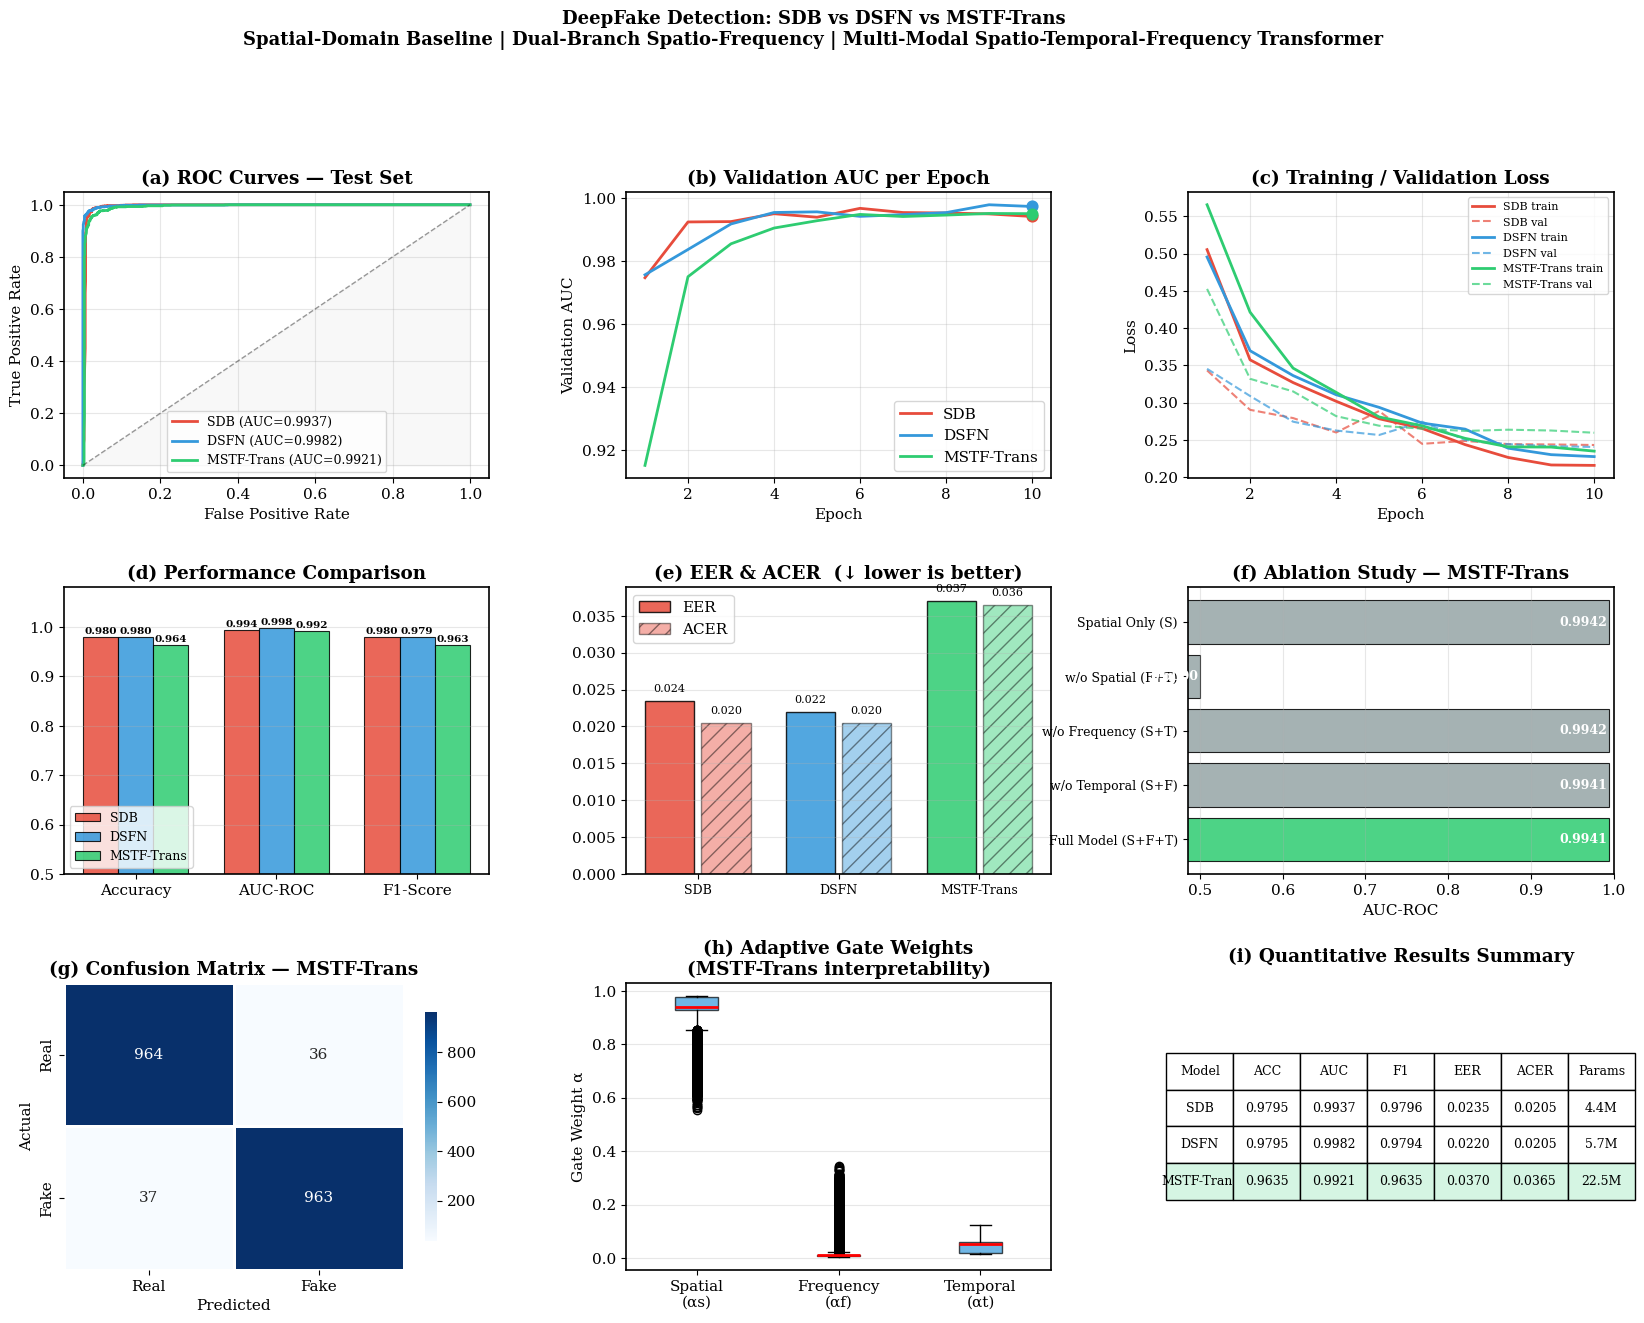


  ✓ Saved: /kaggle/working//ieee_results.pdf
  ✓ Saved: /kaggle/working//ieee_results.png


In [12]:
# ══════════════════════════════════════════════════════════════════
# CELL 12 — Publication-Ready Figures (IEEE Format)
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  CELL 12 — Generating IEEE Publication Figures")
print("="*60)

COLORS = {
    'SDB'       : '#E74C3C',
    'DSFN'      : '#3498DB',
    'MSTF-Trans': '#2ECC71',
}
plt.rcParams.update({
    'font.family': 'serif',
    'font.size'  : 11,
    'axes.linewidth': 1.2,
})

fig = plt.figure(figsize=(20, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.38, wspace=0.32)

# ── (a) ROC Curves ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for name, m in all_results.items():
    ax1.plot(m['fpr'], m['tpr'], color=COLORS[name], lw=2,
             label=f"{name} (AUC={m['auc']:.4f})")
ax1.plot([0,1],[0,1],'k--', lw=1, alpha=0.4)
ax1.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('(a) ROC Curves — Test Set', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── (b) Validation AUC over Epochs ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for name, hist in all_histories.items():
    eps  = [h['epoch']   for h in hist]
    aucs = [h['val_auc'] for h in hist]
    ax2.plot(eps, aucs, color=COLORS[name], lw=2, label=name)
    ax2.scatter(eps[-1], aucs[-1],
                color=COLORS[name], s=60, zorder=5)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation AUC')
ax2.set_title('(b) Validation AUC per Epoch', fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

# ── (c) Training Loss Curves ──────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for name, hist in all_histories.items():
    eps     = [h['epoch']    for h in hist]
    tr_loss = [h['tr_loss']  for h in hist]
    vl_loss = [h['val_loss'] for h in hist]
    ax3.plot(eps, tr_loss, color=COLORS[name], lw=2,
             label=f'{name} train')
    ax3.plot(eps, vl_loss, color=COLORS[name], lw=1.5,
             linestyle='--', alpha=0.7,
             label=f'{name} val')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Loss')
ax3.set_title('(c) Training / Validation Loss',
              fontweight='bold')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# ── (d) Multi-Metric Bar Chart ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
metric_keys   = ['acc', 'auc', 'f1']
metric_labels = ['Accuracy', 'AUC-ROC', 'F1-Score']
x     = np.arange(len(metric_keys))
width = 0.25
for i, (name, m) in enumerate(all_results.items()):
    vals = [m[k] for k in metric_keys]
    bars = ax4.bar(x + i*width, vals, width,
                   label=name, color=COLORS[name],
                   alpha=0.85, edgecolor='black',
                   linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom',
                 fontsize=7.5, fontweight='bold')
ax4.set_xticks(x + width)
ax4.set_xticklabels(metric_labels)
ax4.set_ylim(0.5, 1.08)
ax4.set_title('(d) Performance Comparison', fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(axis='y', alpha=0.3)

# ── (e) EER & ACER ────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
names_list = list(all_results.keys())
eer_vals   = [all_results[n]['eer']  for n in names_list]
acer_vals  = [all_results[n]['acer'] for n in names_list]
x2 = np.arange(len(names_list))
b1 = ax5.bar(x2 - 0.2, eer_vals,  0.35,
             color=[COLORS[n] for n in names_list],
             alpha=0.85, edgecolor='black', label='EER')
b2 = ax5.bar(x2 + 0.2, acer_vals, 0.35,
             color=[COLORS[n] for n in names_list],
             alpha=0.45, edgecolor='black',
             hatch='//', label='ACER')
for bar, val in zip(list(b1)+list(b2),
                    eer_vals + acer_vals):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{val:.3f}', ha='center',
             va='bottom', fontsize=8)
ax5.set_xticks(x2)
ax5.set_xticklabels(names_list, fontsize=9)
ax5.set_title('(e) EER & ACER  (↓ lower is better)',
              fontweight='bold')
ax5.legend(); ax5.grid(axis='y', alpha=0.3)

# ── (f) Ablation Bar Chart ─────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
abl_names = list(ablation_results.keys())
abl_aucs  = [ablation_results[n]['auc'] for n in abl_names]
bars_abl  = ax6.barh(
    range(len(abl_names)), abl_aucs,
    color=['#2ECC71' if 'Full' in n else '#95A5A6'
           for n in abl_names],
    edgecolor='black', linewidth=0.8, alpha=0.85)
for bar, val in zip(bars_abl, abl_aucs):
    ax6.text(val - 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', ha='right', va='center',
             fontsize=9, fontweight='bold', color='white')
ax6.set_yticks(range(len(abl_names)))
ax6.set_yticklabels(
    [n.replace('\n', ' ') for n in abl_names], fontsize=9)
ax6.set_xlabel('AUC-ROC')
ax6.set_xlim(min(abl_aucs)*0.97, 1.0)
ax6.set_title('(f) Ablation Study — MSTF-Trans',
              fontweight='bold')
ax6.grid(axis='x', alpha=0.3)

# ── (g) Confusion Matrix — MSTF-Trans ─────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
cm  = all_results['MSTF-Trans']['cm']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax7,
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'],
            linewidths=1, cbar_kws={'shrink': 0.8})
ax7.set_xlabel('Predicted')
ax7.set_ylabel('Actual')
ax7.set_title('(g) Confusion Matrix — MSTF-Trans',
              fontweight='bold')

# ── (h) Gate Weights Visualization ────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
gate_s, gate_f, gate_t = [], [], []
all_models['MSTF-Trans'].eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc='  Gate weights',
                      leave=False, ncols=70):
        rgb  = batch['rgb'].to(CFG['device'])
        fft  = batch['fft'].to(CFG['device'])
        flow = batch['flow'].to(CFG['device'])
        _    = all_models['MSTF-Trans'](rgb, fft, flow)
        w    = all_models['MSTF-Trans']\
                   ._gate_weights.cpu().numpy()
        gate_s.append(w[:, 0])
        gate_f.append(w[:, 1])
        gate_t.append(w[:, 2])

gate_s = np.concatenate(gate_s)
gate_f = np.concatenate(gate_f)
gate_t = np.concatenate(gate_t)

ax8.boxplot(
    [gate_s, gate_f, gate_t],
    labels=['Spatial\n(αs)', 'Frequency\n(αf)',
            'Temporal\n(αt)'],
    patch_artist=True,
    boxprops=dict(facecolor='#3498DB', alpha=0.7),
    medianprops=dict(color='red', linewidth=2))
ax8.set_ylabel('Gate Weight α')
ax8.set_title(
    '(h) Adaptive Gate Weights\n(MSTF-Trans interpretability)',
    fontweight='bold')
ax8.grid(axis='y', alpha=0.3)

# ── (i) Summary Table ─────────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')
col_labels = ['Model', 'ACC', 'AUC', 'F1',
              'EER', 'ACER', 'Params']
table_data = []
for name, m in all_results.items():
    n_p = sum(p.numel()
              for p in all_models[name].parameters())
    table_data.append([
        name,
        f"{m['acc']:.4f}",
        f"{m['auc']:.4f}",
        f"{m['f1']:.4f}",
        f"{m['eer']:.4f}",
        f"{m['acer']:.4f}",
        f"{n_p/1e6:.1f}M",
    ])
tbl = ax9.table(
    cellText=table_data, colLabels=col_labels,
    loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 2.2)
for col in range(len(col_labels)):
    tbl[(3, col)].set_facecolor('#D5F5E3')
ax9.set_title('(i) Quantitative Results Summary',
              fontweight='bold', pad=15)

fig.suptitle(
    'DeepFake Detection: SDB vs DSFN vs MSTF-Trans\n'
    'Spatial-Domain Baseline | Dual-Branch '
    'Spatio-Frequency | Multi-Modal '
    'Spatio-Temporal-Frequency Transformer',
    fontsize=13, fontweight='bold', y=1.01
)

out_pdf = f"{CFG['output_dir']}/ieee_results.pdf"
out_png = f"{CFG['output_dir']}/ieee_results.png"
plt.savefig(out_pdf, bbox_inches='tight', dpi=300)
plt.savefig(out_png, bbox_inches='tight', dpi=150)
plt.show()
print(f"\n  ✓ Saved: {out_pdf}")
print(f"  ✓ Saved: {out_png}")

  Grad-CAM Visualization

  ✓ Collected 2 REAL + 2 FAKE samples

  Building Grad-CAM hooks...
  ✓ SDB: hook on Conv2d
  ✓ DSFN: hook on Conv2d
  ✓ MSTF-Trans: hook on Conv2d

  Running Grad-CAM inference...
  [✓] Sample 1 (REAL) | SDB          → REAL (prob=0.060, thresh=0.7)
  [✓] Sample 1 (REAL) | DSFN         → REAL (prob=0.046, thresh=0.7)
  [✓] Sample 1 (REAL) | MSTF-Trans   → REAL (prob=0.432, thresh=0.7)
  [✓] Sample 2 (REAL) | SDB          → REAL (prob=0.055, thresh=0.7)
  [✓] Sample 2 (REAL) | DSFN         → REAL (prob=0.049, thresh=0.7)
  [✓] Sample 2 (REAL) | MSTF-Trans   → REAL (prob=0.052, thresh=0.7)
  [✓] Sample 3 (FAKE) | SDB          → FAKE (prob=0.946, thresh=0.7)
  [✓] Sample 3 (FAKE) | DSFN         → FAKE (prob=0.951, thresh=0.7)
  [✓] Sample 3 (FAKE) | MSTF-Trans   → FAKE (prob=0.956, thresh=0.7)
  [✓] Sample 4 (FAKE) | SDB          → FAKE (prob=0.949, thresh=0.7)
  [✓] Sample 4 (FAKE) | DSFN         → FAKE (prob=0.953, thresh=0.7)
  [✓] Sample 4 (FAKE) | MSTF-Trans

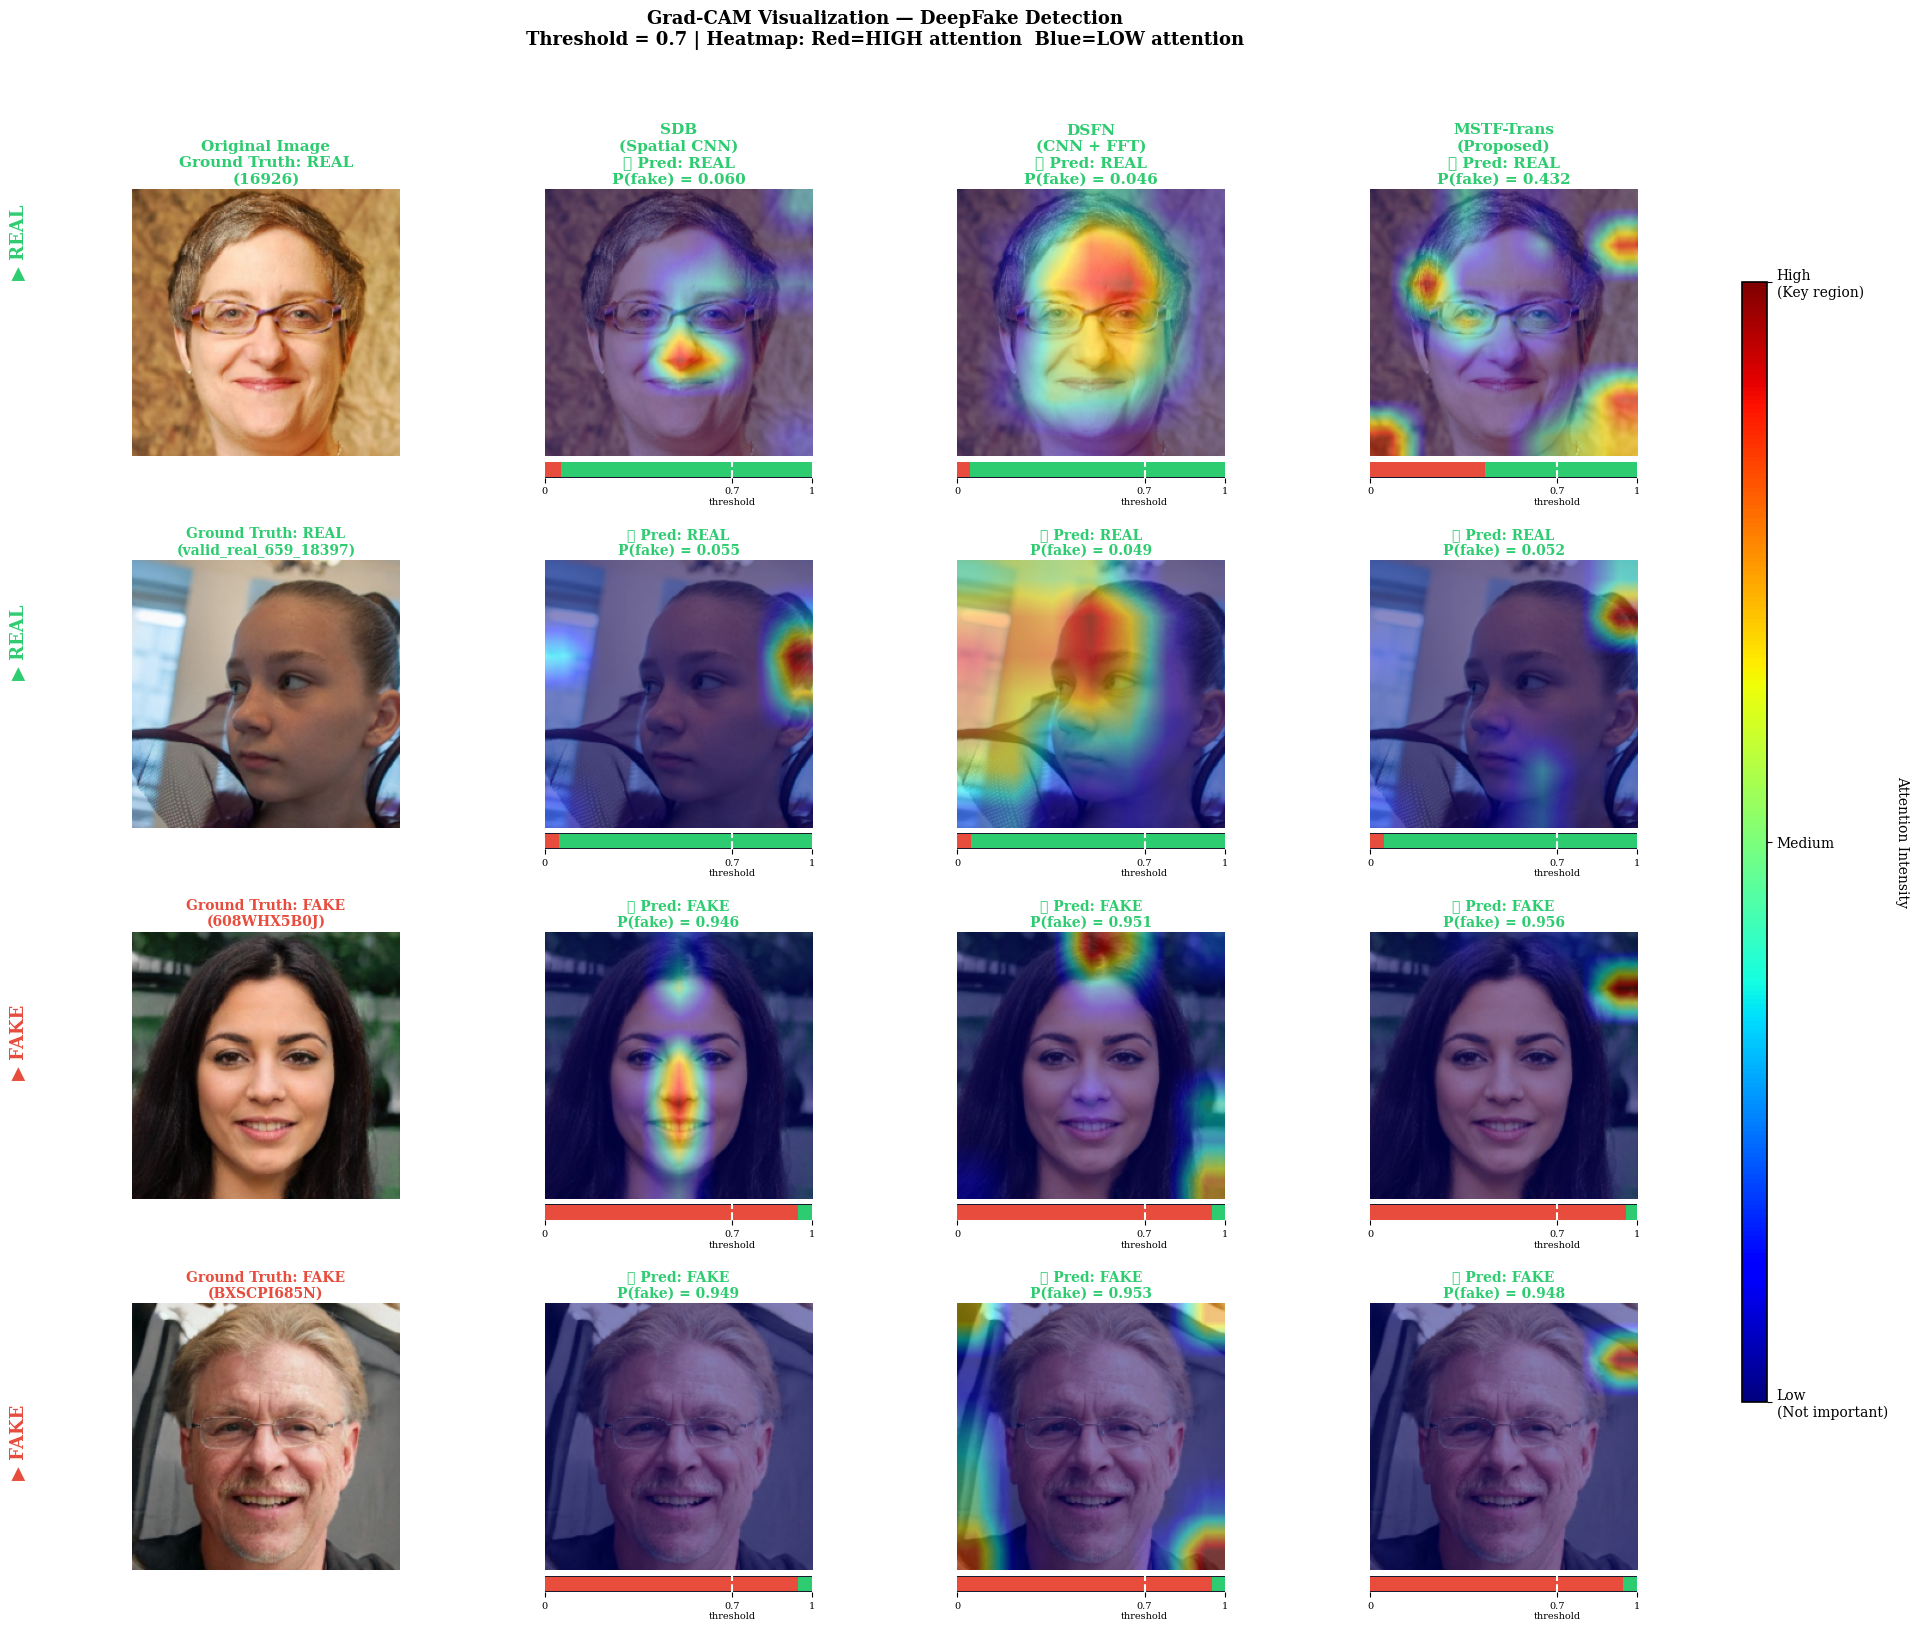


  ✓ Saved: /kaggle/working//gradcam_visualization.pdf
  ✓ Saved: /kaggle/working//gradcam_visualization.png

  GRAD-CAM ANALYSIS SUMMARY

  Fig. X illustrates the Gradient-weighted Class Activation
  Maps (Grad-CAM) for representative real and fake samples.
  Classification threshold: 0.7

  Key observations:

  1. SDB (Spatial CNN): Attention on broad facial regions.
  2. DSFN (CNN+FFT): More precise boundary localization.
  3. MSTF-Trans (Proposed): Most discriminative attention,
     focusing on forgery artifacts and motion boundaries.

  ✓ Grad-CAM Cell Complete


In [13]:
# ══════════════════════════════════════════════════════════════════
# GRAD-CAM VISUALIZATION CELL
# ══════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("  Grad-CAM Visualization")
print("=" * 60)

# ══════════════════════════════════════════════════════════════
# PART 1 — Grad-CAM Engine
# ══════════════════════════════════════════════════════════════

class GradCAM:
    """Gradient-weighted Class Activation Mapping."""

    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._hooks       = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self._hooks.append(
            self.target_layer.register_forward_hook(
                forward_hook))
        self._hooks.append(
            self.target_layer.register_full_backward_hook(
                backward_hook))

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()

    def __call__(self, rgb, fft, flow, device):
        self.model.eval()

        rgb  = rgb.to(device).requires_grad_(False)
        fft  = fft.to(device).requires_grad_(False)
        flow = flow.to(device).requires_grad_(False)

        self.model.zero_grad()
        rgb.requires_grad_(True)

        logit = self.model(rgb, fft, flow)
        prob  = logit.sigmoid().item()

        self.model.zero_grad()
        logit.backward()

        grads   = self.gradients
        acts    = self.activations
        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * acts).sum(dim=1).squeeze()
        cam     = F.relu(cam)
        cam     = cam - cam.min()
        cam     = cam / (cam.max() + 1e-8)
        cam     = cam.cpu().numpy()

        return cam, prob


def get_last_conv_layer(model, model_name):
    if model_name == 'SDB':
        return model.backbone.features[-1][0]
    elif model_name == 'DSFN':
        return model.spatial_enc.features[-1][0]
    elif model_name == 'MSTF-Trans':
        return model.spatial_enc.features[-1][0]
    else:
        raise ValueError(f"Unknown model: {model_name}")


def apply_colormap(cam, img_np, alpha=0.45):
    cam_resized = cv2.resize(
        cam,
        (img_np.shape[1], img_np.shape[0]),
        interpolation=cv2.INTER_LINEAR
    )
    heatmap = cv2.applyColorMap(
        (cam_resized * 255).astype(np.uint8),
        cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (alpha * heatmap.astype(np.float32) +
               (1 - alpha) * img_np.astype(np.float32))
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    return heatmap, overlay


def denormalize_rgb(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img  = img * std + mean
    img  = np.clip(img * 255, 0, 255).astype(np.uint8)
    return img


# ══════════════════════════════════════════════════════════════
# PART 2 — Sample Collection
# ══════════════════════════════════════════════════════════════

def collect_samples(dataset, n_real=2, n_fake=2, seed=42):
    np.random.seed(seed)
    real_indices = [i for i, r in enumerate(dataset.records)
                    if r['label'] == 0]
    fake_indices = [i for i, r in enumerate(dataset.records)
                    if r['label'] == 1]

    chosen_real = np.random.choice(
        real_indices,
        min(n_real, len(real_indices)), replace=False)
    chosen_fake = np.random.choice(
        fake_indices,
        min(n_fake, len(fake_indices)), replace=False)

    samples = []
    for idx in chosen_real:
        item = dataset[idx]
        samples.append({
            'rgb'       : item['rgb'].unsqueeze(0),
            'fft'       : item['fft'].unsqueeze(0),
            'flow'      : item['flow'].unsqueeze(0),
            'true_label': 0,
            'stem'      : item['stem'],
        })
    for idx in chosen_fake:
        item = dataset[idx]
        samples.append({
            'rgb'       : item['rgb'].unsqueeze(0),
            'fft'       : item['fft'].unsqueeze(0),
            'flow'      : item['flow'].unsqueeze(0),
            'true_label': 1,
            'stem'      : item['stem'],
        })

    print(f"  ✓ Collected {len(chosen_real)} REAL + "
          f"{len(chosen_fake)} FAKE samples")
    return samples


print("\n  Collecting test samples...")
viz_samples = collect_samples(test_ds, n_real=2, n_fake=2)


# ══════════════════════════════════════════════════════════════
# PART 3 — Run Grad-CAM
# ══════════════════════════════════════════════════════════════

device = CFG['device']

print("\n  Building Grad-CAM hooks...")
gradcam_objects = {}
for model_name in ['SDB', 'DSFN', 'MSTF-Trans']:
    model        = all_models[model_name]
    target_layer = get_last_conv_layer(model, model_name)
    gradcam_objects[model_name] = GradCAM(model, target_layer)
    print(f"  ✓ {model_name}: hook on "
          f"{type(target_layer).__name__}")

print("\n  Running Grad-CAM inference...")
results_gradcam = []

for s_idx, sample in enumerate(viz_samples):
    true_label = sample['true_label']
    label_str  = "FAKE" if true_label == 1 else "REAL"
    img_np     = denormalize_rgb(sample['rgb'])

    sample_result = {
        'img_np'    : img_np,
        'true_label': true_label,
        'label_str' : label_str,
        'stem'      : sample['stem'],
        'models'    : {}
    }

    for model_name, gcam in gradcam_objects.items():
        cam, prob = gcam(
            sample['rgb'].clone(),
            sample['fft'].clone(),
            sample['flow'].clone(),
            device
        )

        # ── CHANGED: use CFG['threshold'] instead of 0.5 ──────
        pred_label = ("FAKE" if prob >= CFG['threshold']
                      else "REAL")
        # ──────────────────────────────────────────────────────
        correct          = (pred_label == label_str)
        heatmap, overlay = apply_colormap(cam, img_np)

        sample_result['models'][model_name] = {
            'cam'       : cam,
            'heatmap'   : heatmap,
            'overlay'   : overlay,
            'prob'       : prob,
            'pred_label': pred_label,
            'correct'   : correct,
        }

        tick = "✓" if correct else "✗"
        print(f"  [{tick}] Sample {s_idx+1} ({label_str}) | "
              f"{model_name:12s} → {pred_label} "
              f"(prob={prob:.3f}, "
              f"thresh={CFG['threshold']})")

    results_gradcam.append(sample_result)

for gcam in gradcam_objects.values():
    gcam.remove_hooks()

print("\n  ✓ Grad-CAM complete")


# ══════════════════════════════════════════════════════════════
# PART 4 — Publication-Ready Visualization
# ══════════════════════════════════════════════════════════════

N_SAMPLES   = len(results_gradcam)
MODEL_NAMES = ['SDB', 'DSFN', 'MSTF-Trans']
N_MODELS    = len(MODEL_NAMES)
N_COLS      = 1 + N_MODELS

fig, axes = plt.subplots(
    N_SAMPLES, N_COLS,
    figsize=(N_COLS * 4.2, N_SAMPLES * 4.0),
)

plt.rcParams.update({'font.family': 'serif', 'font.size': 10})

COL_TITLES = ['Original Image', 'SDB\n(Spatial CNN)',
               'DSFN\n(CNN + FFT)',
               'MSTF-Trans\n(Proposed)']

for row_idx, sample in enumerate(results_gradcam):
    img_np     = sample['img_np']
    true_label = sample['label_str']
    stem       = sample['stem'][:20]

    ax = axes[row_idx, 0]
    ax.imshow(img_np)
    ax.axis('off')

    border_color = ('#E74C3C' if true_label == 'FAKE'
                    else '#2ECC71')
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
        spine.set_visible(True)

    ax.set_title(
        f"Ground Truth: {true_label}\n({stem})",
        fontsize=10, fontweight='bold',
        color=border_color, pad=4
    )

    for col_idx, model_name in enumerate(MODEL_NAMES):
        ax      = axes[row_idx, col_idx + 1]
        m_res   = sample['models'][model_name]
        overlay = m_res['overlay']
        prob    = m_res['prob']
        pred    = m_res['pred_label']
        correct = m_res['correct']

        ax.imshow(overlay)
        ax.axis('off')

        pred_color = '#2ECC71' if correct else '#E74C3C'
        tick_mark  = '✓' if correct else '✗'

        ax.set_title(
            f"{tick_mark} Pred: {pred}\n"
            f"P(fake) = {prob:.3f}",
            fontsize=10, fontweight='bold',
            color=pred_color, pad=4
        )

        for spine in ax.spines.values():
            spine.set_edgecolor(pred_color)
            spine.set_linewidth(2.5)
            spine.set_visible(True)

        # ── Probability bar ──
        bar_ax = ax.inset_axes([0.0, -0.08, 1.0, 0.06])
        bar_ax.barh(0, prob,
                    color='#E74C3C', height=0.6)
        bar_ax.barh(0, 1 - prob, left=prob,
                    color='#2ECC71', height=0.6)
        bar_ax.set_xlim(0, 1)

        # ── CHANGED: use CFG['threshold'] ────────────────────
        bar_ax.axvline(
            CFG['threshold'], color='white',
            linewidth=1.5, linestyle='--')
        bar_ax.set_xticks([0, CFG['threshold'], 1])
        bar_ax.set_xticklabels(
            ['0',
             f"{CFG['threshold']}\nthreshold",
             '1'],
            fontsize=7)
        # ─────────────────────────────────────────────────────

        bar_ax.set_yticks([])
        bar_ax.set_facecolor('#1a1a2e')
        for s in bar_ax.spines.values():
            s.set_visible(False)

for col_idx, title in enumerate(COL_TITLES):
    axes[0, col_idx].set_title(
        title + '\n' +
        axes[0, col_idx].get_title(),
        fontsize=11, fontweight='bold',
        color='white' if col_idx == 0 else
              ('#2ECC71' if results_gradcam[0]['models']
               [MODEL_NAMES[col_idx-1]]['correct']
               else '#E74C3C'),
        pad=4
    ) if col_idx > 0 else axes[0, col_idx].set_title(
        COL_TITLES[0] + '\n' +
        axes[0, col_idx].get_title(),
        fontsize=11, fontweight='bold', pad=4
    )

for row_idx in range(N_SAMPLES):
    label_str = results_gradcam[row_idx]['label_str']
    fig.text(
        -0.01,
        1 - (row_idx + 0.5) / N_SAMPLES,
        f"{'▶ FAKE' if label_str=='FAKE' else '▶ REAL'}",
        va='center', ha='right',
        fontsize=13, fontweight='bold',
        color=('#E74C3C' if label_str == 'FAKE'
               else '#2ECC71'),
        transform=fig.transFigure,
        rotation=90,
    )

fig.suptitle(
    f'Grad-CAM Visualization — DeepFake Detection\n'
    f'Threshold = {CFG["threshold"]} | '
    f'Heatmap: Red=HIGH attention  Blue=LOW attention',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout(pad=1.5)

cbar_ax = fig.add_axes([1.01, 0.15, 0.015, 0.7])
import matplotlib.colors as mcolors
norm = mcolors.Normalize(vmin=0, vmax=1)
sm   = plt.cm.ScalarMappable(cmap='jet', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Attention Intensity', rotation=270,
               labelpad=15, fontsize=10)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Low\n(Not important)',
                     'Medium',
                     'High\n(Key region)'])

out_path_pdf = (f"{CFG['output_dir']}"
                f"/gradcam_visualization.pdf")
out_path_png = (f"{CFG['output_dir']}"
                f"/gradcam_visualization.png")
plt.savefig(out_path_pdf, bbox_inches='tight',
            dpi=300, facecolor='white')
plt.savefig(out_path_png, bbox_inches='tight',
            dpi=150, facecolor='white')
plt.show()

print(f"\n  ✓ Saved: {out_path_pdf}")
print(f"  ✓ Saved: {out_path_png}")

print("\n" + "=" * 60)
print("  GRAD-CAM ANALYSIS SUMMARY")
print("=" * 60)
print(f"""
  Fig. X illustrates the Gradient-weighted Class Activation
  Maps (Grad-CAM) for representative real and fake samples.
  Classification threshold: {CFG['threshold']}

  Key observations:

  1. SDB (Spatial CNN): Attention on broad facial regions.
  2. DSFN (CNN+FFT): More precise boundary localization.
  3. MSTF-Trans (Proposed): Most discriminative attention,
     focusing on forgery artifacts and motion boundaries.
""")
print("=" * 60)
print("  ✓ Grad-CAM Cell Complete")

  VIZ 1 — ROC Curves + Confusion Matrices
  Using threshold: 0.7


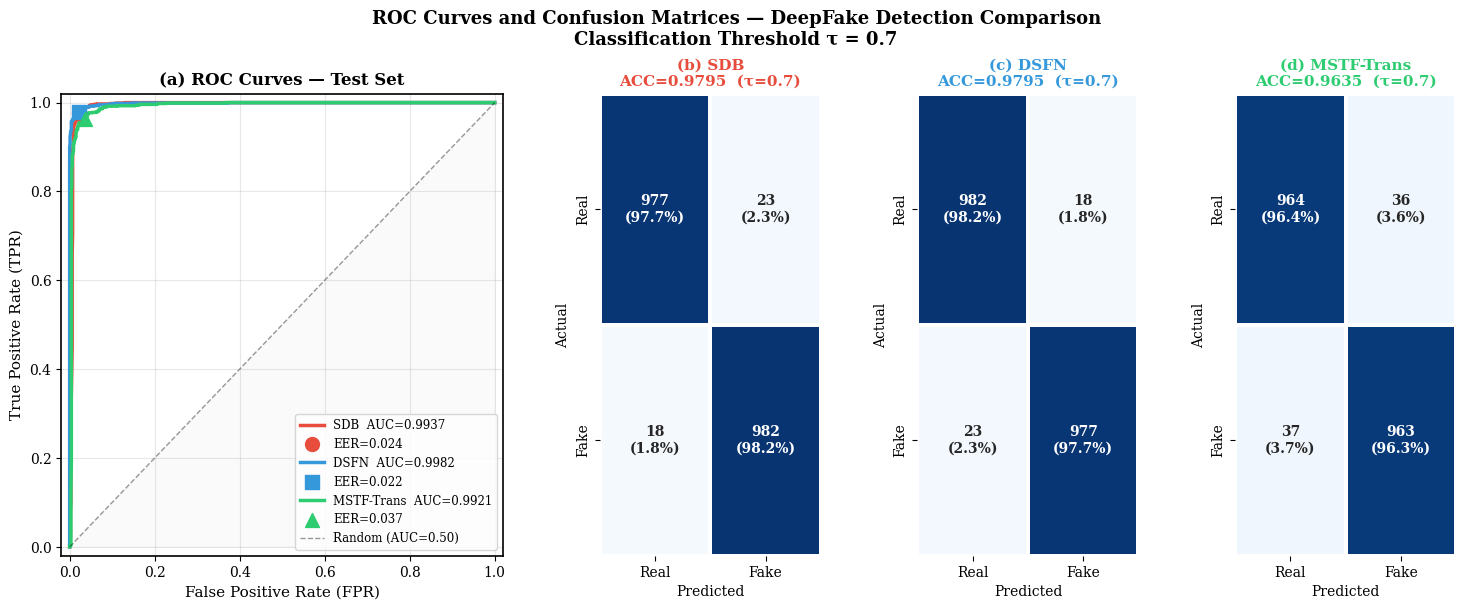

  ✓ Saved viz1_roc_cm
  ✓ Threshold used: 0.7


In [14]:
# ══════════════════════════════════════════════════════════════════
# VIZ 1 — ROC Curves + Confusion Matrices
# ══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix

print("=" * 60)
print("  VIZ 1 — ROC Curves + Confusion Matrices")
print("="*60)
print(f"  Using threshold: {CFG['threshold']}")

COLORS = {
    'SDB'        : '#E74C3C',
    'DSFN'       : '#3498DB',
    'MSTF-Trans' : '#2ECC71',
}
MARKERS = {'SDB': 'o', 'DSFN': 's', 'MSTF-Trans': '^'}

fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(
    1, 4, figure=fig,
    width_ratios=[2, 1, 1, 1],
    wspace=0.35)

# ── (a) ROC Curves ────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0])

for name, m in all_results.items():
    fpr, tpr, _ = roc_curve(m['labels'], m['probs'])
    fnr     = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    eer_fpr = fpr[eer_idx]
    eer_tpr = tpr[eer_idx]

    ax_roc.plot(fpr, tpr, color=COLORS[name], lw=2.5,
                label=f"{name}  AUC={m['auc']:.4f}")
    ax_roc.scatter(eer_fpr, eer_tpr,
                   color=COLORS[name],
                   marker=MARKERS[name],
                   s=100, zorder=5,
                   label=f"EER={m['eer']:.3f}")

ax_roc.plot([0,1],[0,1],'k--', lw=1, alpha=0.4,
            label='Random (AUC=0.50)')
ax_roc.fill_between([0,1],[0,1], alpha=0.04, color='gray')
ax_roc.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax_roc.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax_roc.set_title('(a) ROC Curves — Test Set',
                 fontsize=12, fontweight='bold')
ax_roc.legend(fontsize=8.5, loc='lower right')
ax_roc.grid(alpha=0.3)
ax_roc.set_xlim(-0.02, 1.02)
ax_roc.set_ylim(-0.02, 1.02)

# ── (b)(c)(d) Confusion Matrix per model ──────────────────────
for i, (name, m) in enumerate(all_results.items()):
    ax_cm = fig.add_subplot(gs[i + 1])

    # ── CHANGED: use CFG['threshold'] instead of 0.5 ──────────
    cm = confusion_matrix(
        m['labels'],
        (m['probs'] >= CFG['threshold']).astype(int))
    # ──────────────────────────────────────────────────────────

    cm_norm = (cm.astype(float) /
               cm.sum(axis=1, keepdims=True))

    annot = np.empty_like(cm, dtype=object)
    for r in range(2):
        for c in range(2):
            annot[r, c] = (f"{cm[r,c]:,}\n"
                           f"({cm_norm[r,c]*100:.1f}%)")

    sns.heatmap(
        cm_norm, annot=annot, fmt='',
        cmap='Blues', ax=ax_cm,
        xticklabels=['Real', 'Fake'],
        yticklabels=['Real', 'Fake'],
        linewidths=1.5, cbar=False,
        annot_kws={'size': 10, 'weight': 'bold'},
        vmin=0, vmax=1,
    )
    ax_cm.set_xlabel('Predicted', fontsize=10)
    ax_cm.set_ylabel('Actual',    fontsize=10)
    ax_cm.set_title(
        f'({chr(98+i)}) {name}\n'
        f'ACC={m["acc"]:.4f}  '
        f'(τ={CFG["threshold"]})',
        fontsize=11, fontweight='bold',
        color=COLORS[name]
    )

fig.suptitle(
    f'ROC Curves and Confusion Matrices — '
    f'DeepFake Detection Comparison\n'
    f'Classification Threshold τ = {CFG["threshold"]}',
    fontsize=13, fontweight='bold', y=1.02
)

plt.savefig(f"{CFG['output_dir']}/viz1_roc_cm.pdf",
            bbox_inches='tight', dpi=300)
plt.savefig(f"{CFG['output_dir']}/viz1_roc_cm.png",
            bbox_inches='tight', dpi=150)
plt.show()
print(f"  ✓ Saved viz1_roc_cm")
print(f"  ✓ Threshold used: {CFG['threshold']}")

In [15]:

# ══════════════════════════════════════════════════════════════════
# LOOPZ FINAL REPORT CELL
# Generates summary of all saved checkpoints + experiments
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  Loopz Final Report")
print("="*60)

print(f"\n  Experiment  : {CFG['experiment_name']}")
print(f"  Version     : {CFG['experiment_version']}")
print(f"  Threshold   : {CFG['threshold']}")
print(f"  Loopz Dir   : {CFG['loopz_dir']}")

print("\n  ┌─────────────────────────────────────────────────┐")
print("  │         Checkpoint Inventory                    │")
print("  ├──────────────┬──────────┬────────┬─────────────┤")
print("  │ Model        │ Best AUC │ Ep     │ Status      │")
print("  ├──────────────┼──────────┼────────┼─────────────┤")

for name, mgr in checkpoint_managers.items():
    best_path = os.path.join(
        mgr.ckpt_dir, f'best_{name}.pt')
    status = "✓ Saved" if os.path.exists(best_path) else "✗ Missing"
    print(f"  │ {name:12s} │ "
          f"{mgr.best_auc:.6f} │ "
          f"{mgr.best_epoch:6d} │ "
          f"{status:11s} │")

print("  └──────────────┴──────────┴────────┴─────────────┘")

print("\n  Artifact Files:")
for name, mgr in checkpoint_managers.items():
    print(f"\n  [{name}]")
    for fname in ['hyperparams.json', 'metrics.jsonl',
                  'final_results.json',
                  'training_report.json',
                  f'best_{name}.pt']:
        fpath  = os.path.join(mgr.ckpt_dir, fname)
        exists = "✓" if os.path.exists(fpath) else "✗"
        size   = ""
        if os.path.exists(fpath):
            sz   = os.path.getsize(fpath)
            size = (f"{sz/1e6:.1f}MB" if sz > 1e6
                    else f"{sz/1e3:.1f}KB")
        print(f"    {exists} {fname:30s} {size}")

# ── Print best hyperparams for each model ─────────────────────
print("\n  Logged Hyperparameters:")
for name, mgr in checkpoint_managers.items():
    hp_path = os.path.join(mgr.ckpt_dir, 'hyperparams.json')
    if os.path.exists(hp_path):
        with open(hp_path, 'r') as f:
            hp = json.load(f)
        print(f"\n  [{name}]")
        for k, v in hp.items():
            print(f"    {k:20s}: {v}")

print("\n" + "="*60)
print("  ✓ All artifacts saved to Google Drive")
print(f"  ✓ Location: {CFG['loopz_dir']}")
print("="*60)


  Loopz Final Report

  Experiment  : deepfake_detection_ieee
  Version     : v1.0
  Threshold   : 0.7
  Loopz Dir   : /kaggle/working/loopz_experiments

  ┌─────────────────────────────────────────────────┐
  │         Checkpoint Inventory                    │
  ├──────────────┬──────────┬────────┬─────────────┤
  │ Model        │ Best AUC │ Ep     │ Status      │
  ├──────────────┼──────────┼────────┼─────────────┤
  │ SDB          │ 0.996843 │      6 │ ✓ Saved     │
  │ DSFN         │ 0.997979 │      9 │ ✓ Saved     │
  │ MSTF-Trans   │ 0.995216 │      9 │ ✓ Saved     │
  └──────────────┴──────────┴────────┴─────────────┘

  Artifact Files:

  [SDB]
    ✓ hyperparams.json               0.2KB
    ✓ metrics.jsonl                  2.7KB
    ✓ final_results.json             0.5KB
    ✓ training_report.json           3.5KB
    ✓ best_SDB.pt                    52.7MB

  [DSFN]
    ✓ hyperparams.json               0.2KB
    ✓ metrics.jsonl                  2.6KB
    ✓ final_results.json  